<a href="https://colab.research.google.com/github/ankitaa19/-C/blob/main/letsplaycricket_ankita_44.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lets Play Cricket  - IPL Exploration Analysis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Anybody who is a cricket Fan should surely try to analyse this dataset as it would help you in learning with a fun factor. I have tried my best to keep this notebook as simple as possible so that even a beginner can understand it easily. At the same time I have made efforts to analyse the dataset in different aspects effectively. I will keep updating the notebook as and when I come up with new things. Hope you like it!!!

The notebook contains:
 - Basic Analysis like Teams with maximum matches, wins,etc
 - Batsman Analysis
 - Bowler Analysis
 - 200+ scores analysis

If you like the notebook, **Please Upvote** as it will keep me motivated in doing great things ahead. Thanks!!

I have used the following packages for visualisations:

 1. Matplotlib
 2. Seaborn
 3. Plotly

Not all the visuals are interactive as Plotly is not useful everywhere. I have mentioned **INTERACTIVE** at places where the visuals are inteactive.

Following is a **Tableau Dashboard**. DO have a look at it.

## Tableau Dashboard

In [2]:
%%HTML

<div class='tableauPlaceholder' id='viz1512062244547' style='position: relative'><noscript><a href='#'><img alt='Dashboard 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;IP&#47;IPLDashboard_0&#47;Dashboard1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='IPLDashboard_0&#47;Dashboard1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;IP&#47;IPLDashboard_0&#47;Dashboard1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1512062244547');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='1520px';vizElement.style.height='1787px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

In [4]:
# =========================
# IMPORT LIBRARIES
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as mlt
import seaborn as sns

mlt.style.use('fivethirtyeight')

import plotly.offline as py
py.init_notebook_mode(connected=True)

import plotly.graph_objs as go
import plotly.tools as tls

# =========================
# CHECK FILES IN COLAB
# =========================

import os

print(os.listdir('/content'))

# =========================
# LOAD DATASET
# =========================

delivery = pd.read_csv('/content/deliveries.csv')

# =========================
# SHOW DATA
# =========================

delivery.head()

['.config', 'deliveries.csv', 'drive', 'sample_data']


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [10]:
matches = pd.read_csv('/content/matches.csv')

delivery = pd.read_csv('/content/deliveries 2.csv')

matches.head(2)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN


In [11]:
delivery.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


## Some Cleaning And Transformation

In [15]:
# Remove umpire3 column only if it exists
if 'umpire3' in matches.columns:
    matches.drop(['umpire3'], axis=1, inplace=True)

# Fill missing values
delivery.fillna(0, inplace=True)

# Check missing values
print(matches.isnull().sum())

print(delivery.isnull().sum())

id                 0
season             0
city               7
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             3
win_by_runs        0
win_by_wickets     0
player_of_match    3
venue              0
umpire1            1
umpire2            1
dtype: int64
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batsman             0
non_striker         0
bowler              0
is_super_over       0
wide_runs           0
bye_runs            0
legbye_runs         0
noball_runs         0
penalty_runs        0
batsman_runs        0
extra_runs          0
total_runs          0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64


In [16]:
matches['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [17]:
#Replacing the Team Names with their abbreviations

matches.replace(['Mumbai Indians','Kolkata Knight Riders','Royal Challengers Bangalore','Deccan Chargers','Chennai Super Kings',
                 'Rajasthan Royals','Delhi Daredevils','Gujarat Lions','Kings XI Punjab',
                 'Sunrisers Hyderabad','Rising Pune Supergiants','Kochi Tuskers Kerala','Pune Warriors','Rising Pune Supergiant']
                ,['MI','KKR','RCB','DC','CSK','RR','DD','GL','KXIP','SRH','RPS','KTK','PW','RPS'],inplace=True)

delivery.replace(['Mumbai Indians','Kolkata Knight Riders','Royal Challengers Bangalore','Deccan Chargers','Chennai Super Kings',
                 'Rajasthan Royals','Delhi Daredevils','Gujarat Lions','Kings XI Punjab',
                 'Sunrisers Hyderabad','Rising Pune Supergiants','Kochi Tuskers Kerala','Pune Warriors','Rising Pune Supergiant']
                ,['MI','KKR','RCB','DC','CSK','RR','DD','GL','KXIP','SRH','RPS','KTK','PW','RPS'],inplace=True)

## Some Basic Analysis

In [18]:
print('Total Matches Played:',matches.shape[0])
print(' \n Venues Played At:',matches['city'].unique())
print(' \n Teams :',matches['team1'].unique())

Total Matches Played: 636
 
 Venues Played At: ['Hyderabad' 'Pune' 'Rajkot' 'Indore' 'Bangalore' 'Mumbai' 'Kolkata'
 'Delhi' 'Chandigarh' 'Kanpur' 'Jaipur' 'Chennai' 'Cape Town'
 'Port Elizabeth' 'Durban' 'Centurion' 'East London' 'Johannesburg'
 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur' 'Dharamsala'
 'Kochi' 'Visakhapatnam' 'Raipur' 'Ranchi' 'Abu Dhabi' 'Sharjah' nan]
 
 Teams : ['SRH' 'MI' 'GL' 'RPS' 'RCB' 'KKR' 'DD' 'KXIP' 'CSK' 'RR' 'DC' 'KTK' 'PW']


In [19]:
print('Total venues played at:',matches['city'].nunique())
print('\nTotal umpires ',matches['umpire1'].nunique())

Total venues played at: 30

Total umpires  44


In [20]:
print((matches['player_of_match'].value_counts()).idxmax(),' : has most man of the match awards')
print(((matches['winner']).value_counts()).idxmax(),': has the highest number of match wins')

CH Gayle  : has most man of the match awards
MI : has the highest number of match wins


In [21]:
df=matches.iloc[[matches['win_by_runs'].idxmax()]]
df[['season','team1','team2','winner','win_by_runs']]

,season,team1,team2,winner,win_by_runs
43,2017,MI,DD,MI,146


Mumbai Indians(MI) defeated Delhi Daredevils(DD) with the highest run difference

In [22]:
df=matches.iloc[[matches['win_by_wickets'].idxmax()]]
df[['season','team1','team2','winner','win_by_wickets']]

,season,team1,team2,winner,win_by_wickets
2,2017,GL,KKR,KKR,10


Kolkata Knight Riders(KKR) defeated Gujrat Lions(GL) with the highest wins by wickets

## Toss Decisions

In [23]:
print('Toss Decisions in %\n',((matches['toss_decision']).value_counts())/577*100)

Toss Decisions in %
 toss_decision
field    62.911612
bat      47.313692
Name: count, dtype: float64


### Toss Decisions across Seasons

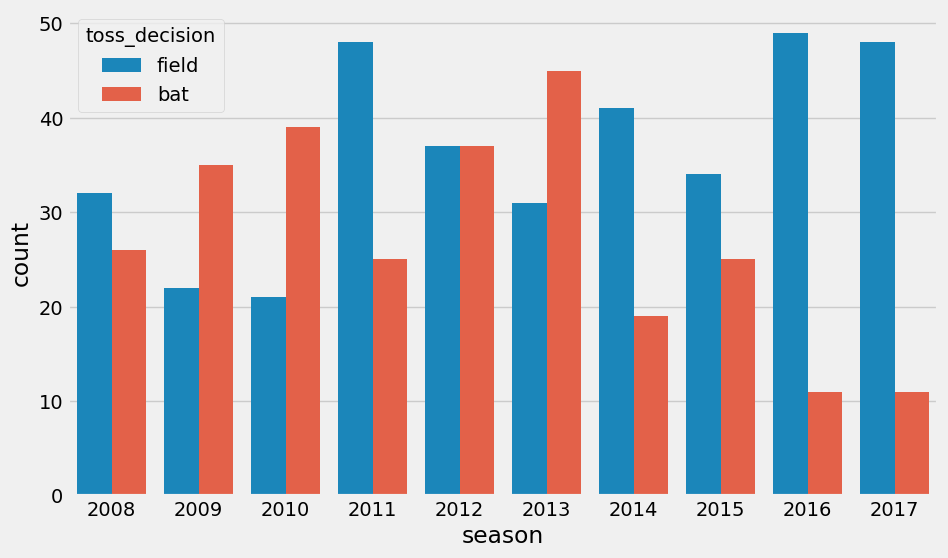

In [24]:
mlt.subplots(figsize=(10,6))
sns.countplot(x='season',hue='toss_decision',data=matches)
mlt.show()

The decision for batting or fielding varies largely across the seasons. In some seasons, the probablity that toss winners opt for batting is high, while it is not the case in other seasons. In 2016 though, the majority of toss winners opted for batting.

### Maximum Toss Winners

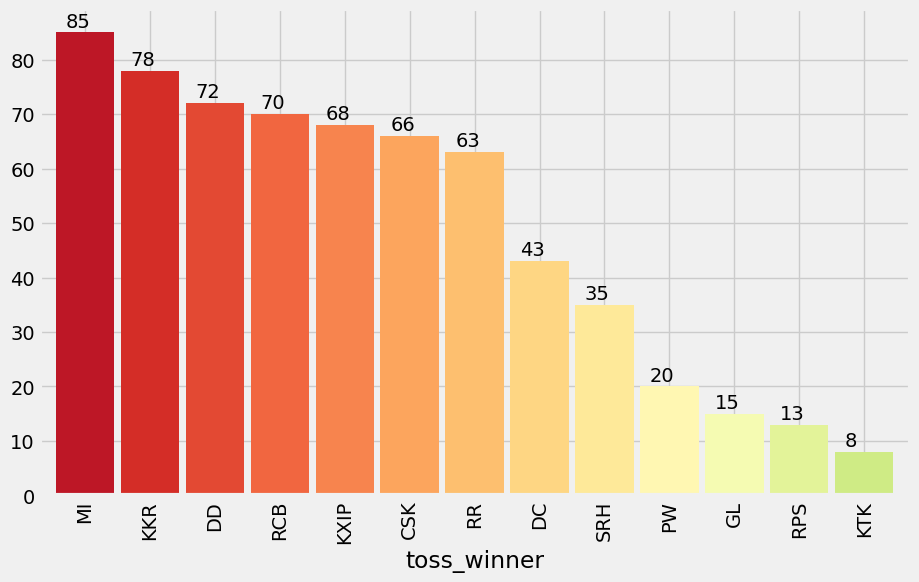

In [25]:
mlt.subplots(figsize=(10,6))
ax=matches['toss_winner'].value_counts().plot.bar(width=0.9,color=sns.color_palette('RdYlGn',20))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x()+0.15, p.get_height()+1))
mlt.show()

Mumbai Indians seem to be very lucky having the higest win in tosses follwed by Kolkata Knight Riders. Pune Supergiants have the lowest wins as they have played the lowest matches also. This does not show the higher chances of winning the toss as the number of matches played by each team is uneven.

### Total Matches vs Wins for Teams (INTERACTIVE)

In [26]:
matches_played_byteams=pd.concat([matches['team1'],matches['team2']])
matches_played_byteams=matches_played_byteams.value_counts().reset_index()
matches_played_byteams.columns=['Team','Total Matches']
matches_played_byteams['wins']=matches['winner'].value_counts().reset_index()['winner']
matches_played_byteams.set_index('Team',inplace=True)

trace1 = go.Bar(
    x=matches_played_byteams.index,
    y=matches_played_byteams['Total Matches'],
    name='Total Matches'
)
trace2 = go.Bar(
    x=matches_played_byteams.index,
    y=matches_played_byteams['wins'],
    name='Matches Won'
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='stack'
)

fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

### Is Toss Winner Also the Match Winner?

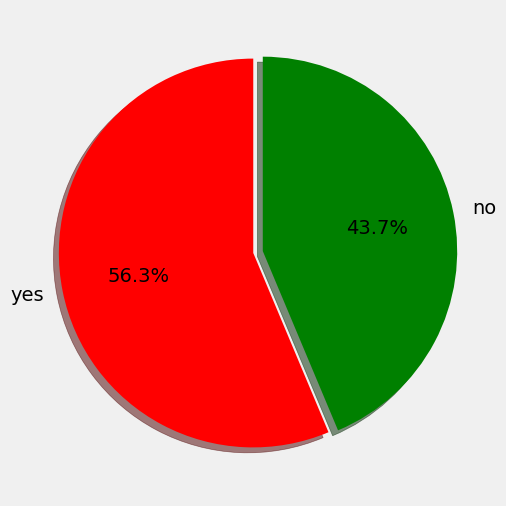

In [27]:
df=matches[matches['toss_winner']==matches['winner']]
slices=[len(df),(577-len(df))]
labels=['yes','no']
mlt.pie(slices,labels=labels,startangle=90,shadow=True,explode=(0,0.05),autopct='%1.1f%%',colors=['r','g'])
fig = mlt.gcf()
fig.set_size_inches(6,6)
mlt.show()

Thus the toss winner is not necessarily the match winner. The match winning probablity for toss winnong team is about 50%-50%

##  Matches played across each season

/tmp/ipykernel_2039/4278690967.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2039/4278690967.py:2: UserWarning:


The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.



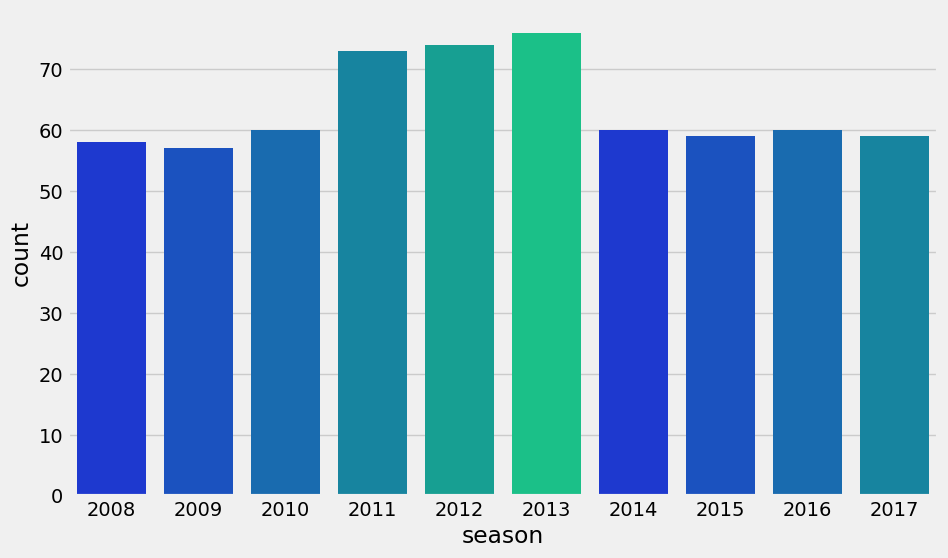

In [28]:
mlt.subplots(figsize=(10,6))
sns.countplot(x='season',data=matches,palette=sns.color_palette('winter'))  #countplot automatically counts the frequency of an item
mlt.show()

### Runs Across the Seasons

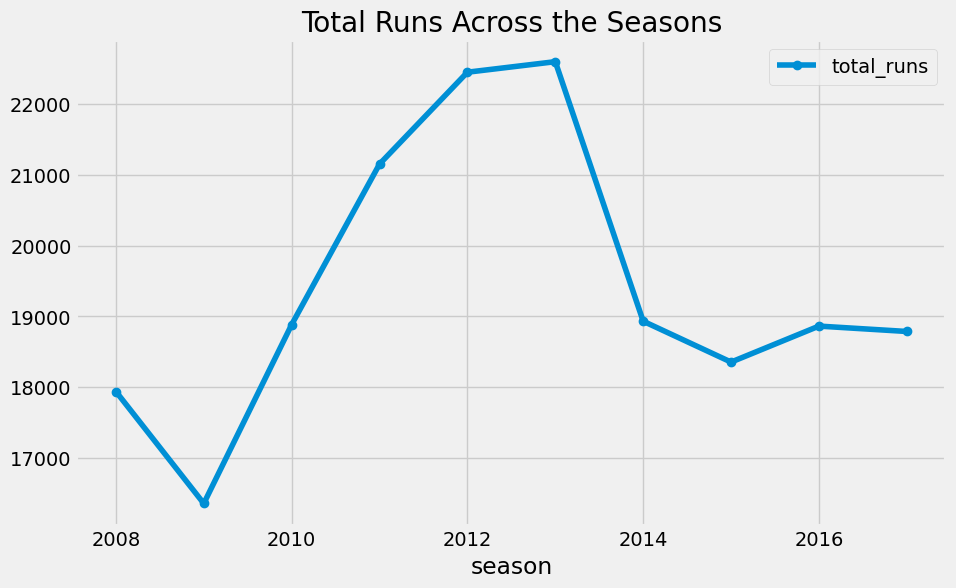

In [29]:
batsmen = matches[['id','season']].merge(delivery, left_on = 'id', right_on = 'match_id', how = 'left').drop('id', axis = 1)
#merging the matches and delivery dataframe by referencing the id and match_id columns respectively
season=batsmen.groupby(['season'])['total_runs'].sum().reset_index()
season.set_index('season').plot(marker='o')
mlt.gcf().set_size_inches(10,6)
mlt.title('Total Runs Across the Seasons')
mlt.show()

There was a decline in total runs from 2008 to 2009.But there after there was a substantial increase in runs in every season until 2013, but from next season there was a slump in the total runs. But the number of matches are not equal in all seasons. We should check the average runs per match in each season

### Average runs per match in each Season

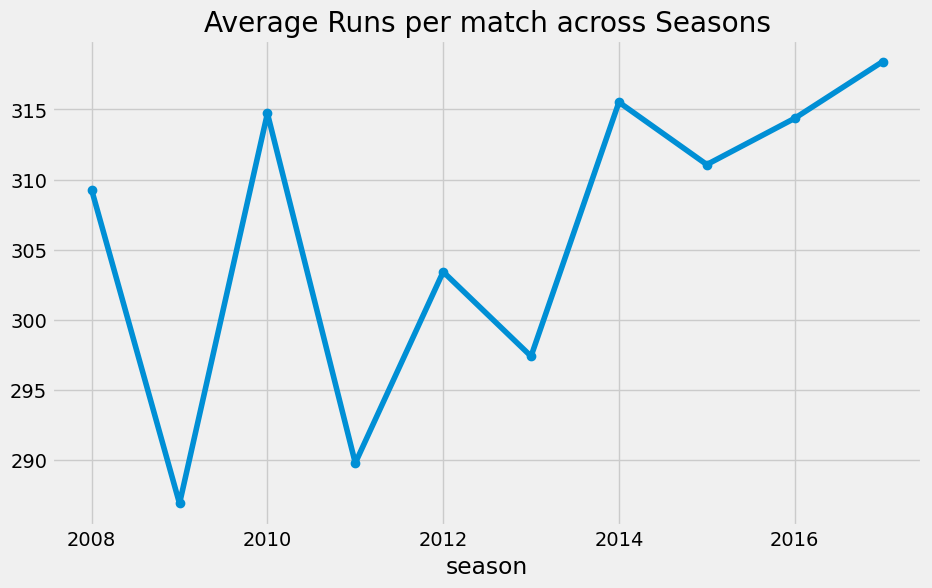

In [30]:
avgruns_each_season=matches.groupby(['season']).count().id.reset_index()
avgruns_each_season.rename(columns={'id':'matches'},inplace=1)
avgruns_each_season['total_runs']=season['total_runs']
avgruns_each_season['average_runs_per_match']=avgruns_each_season['total_runs']/avgruns_each_season['matches']
avgruns_each_season.set_index('season')['average_runs_per_match'].plot(marker='o')
mlt.gcf().set_size_inches(10,6)
mlt.title('Average Runs per match across Seasons')
mlt.show()

### Sixes and Fours Across the Season

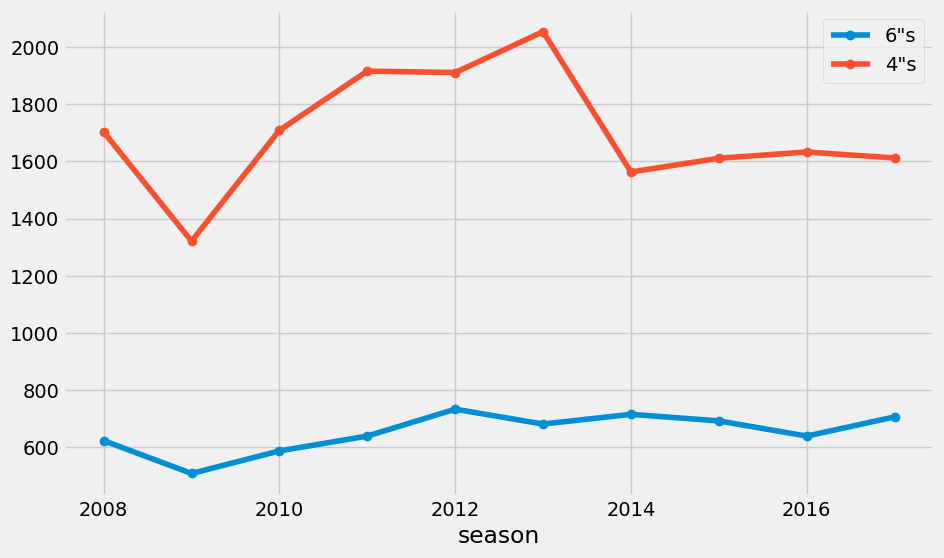

In [31]:
Season_boundaries=batsmen.groupby("season")["batsman_runs"].agg(lambda x: (x==6).sum()).reset_index()
a=batsmen.groupby("season")["batsman_runs"].agg(lambda x: (x==4).sum()).reset_index()
Season_boundaries=Season_boundaries.merge(a,left_on='season',right_on='season',how='left')
Season_boundaries=Season_boundaries.rename(columns={'batsman_runs_x':'6"s','batsman_runs_y':'4"s'})
Season_boundaries.set_index('season')[['6"s','4"s']].plot(marker='o')
fig=mlt.gcf()
fig.set_size_inches(10,6)
mlt.show()

### Runs Per Over By Teams Across Seasons

/tmp/ipykernel_2039/1696738432.py:1: FutureWarning:

The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



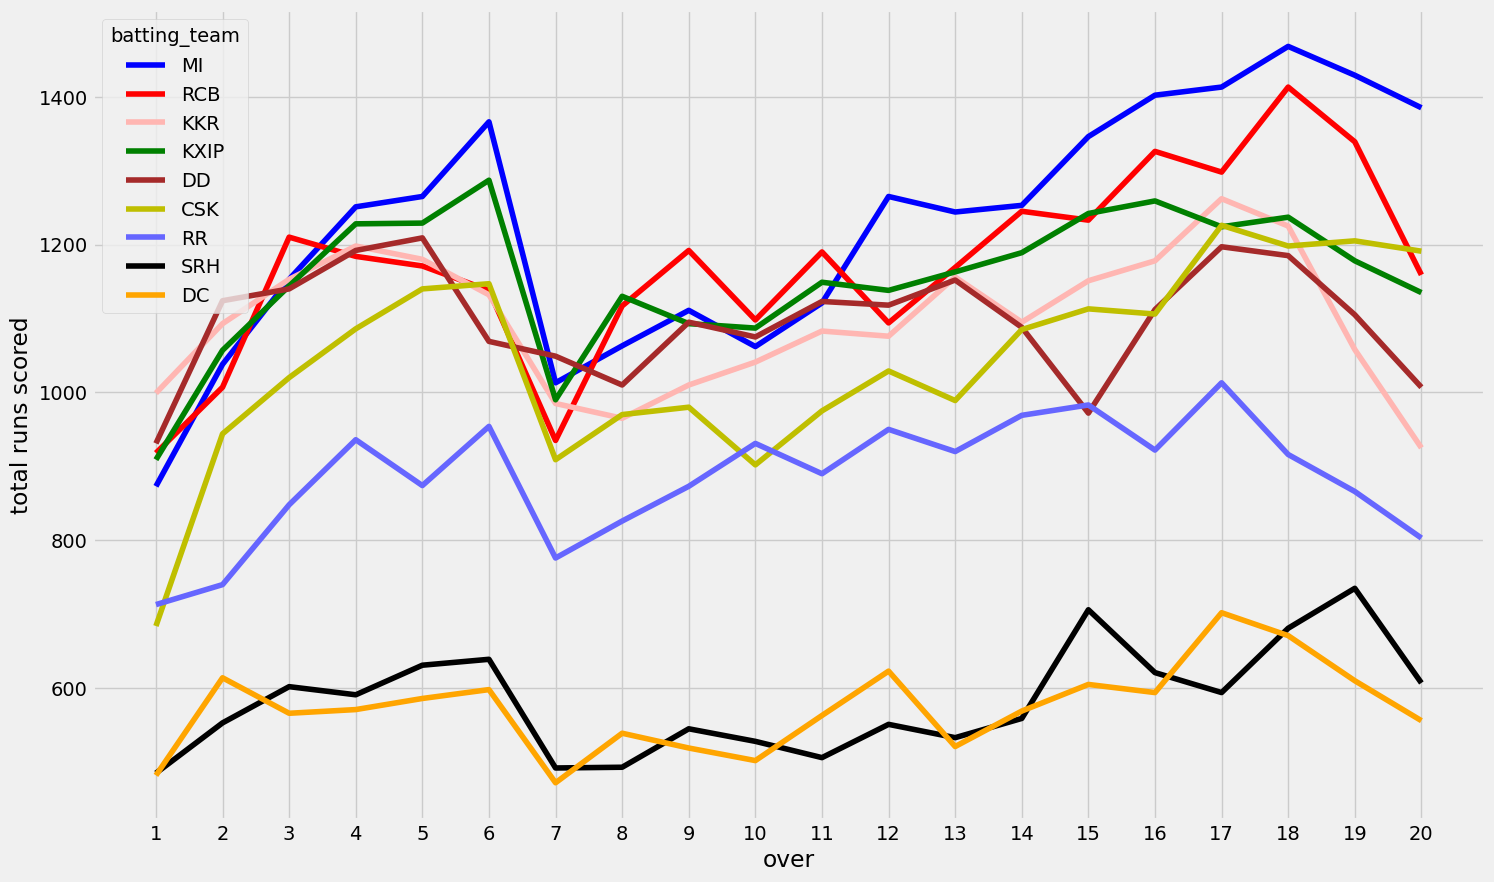

In [32]:
runs_per_over = delivery.pivot_table(index=['over'],columns='batting_team',values='total_runs',aggfunc=sum)
runs_per_over[(matches_played_byteams[matches_played_byteams['Total Matches']>50].index)].plot(color=["b", "r", "#Ffb6b2", "g",'brown','y','#6666ff','black','#FFA500']) #plotting graphs for teams that have played more than 100 matches
x=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
mlt.xticks(x)
mlt.ylabel('total runs scored')
fig=mlt.gcf()
fig.set_size_inches(16,10)
mlt.show()

Maximum runs are being scored in the last 5 overs of the match. MI and RCB have shown a incresing trend in the runs scored throughout the match.

### Favorite Grounds

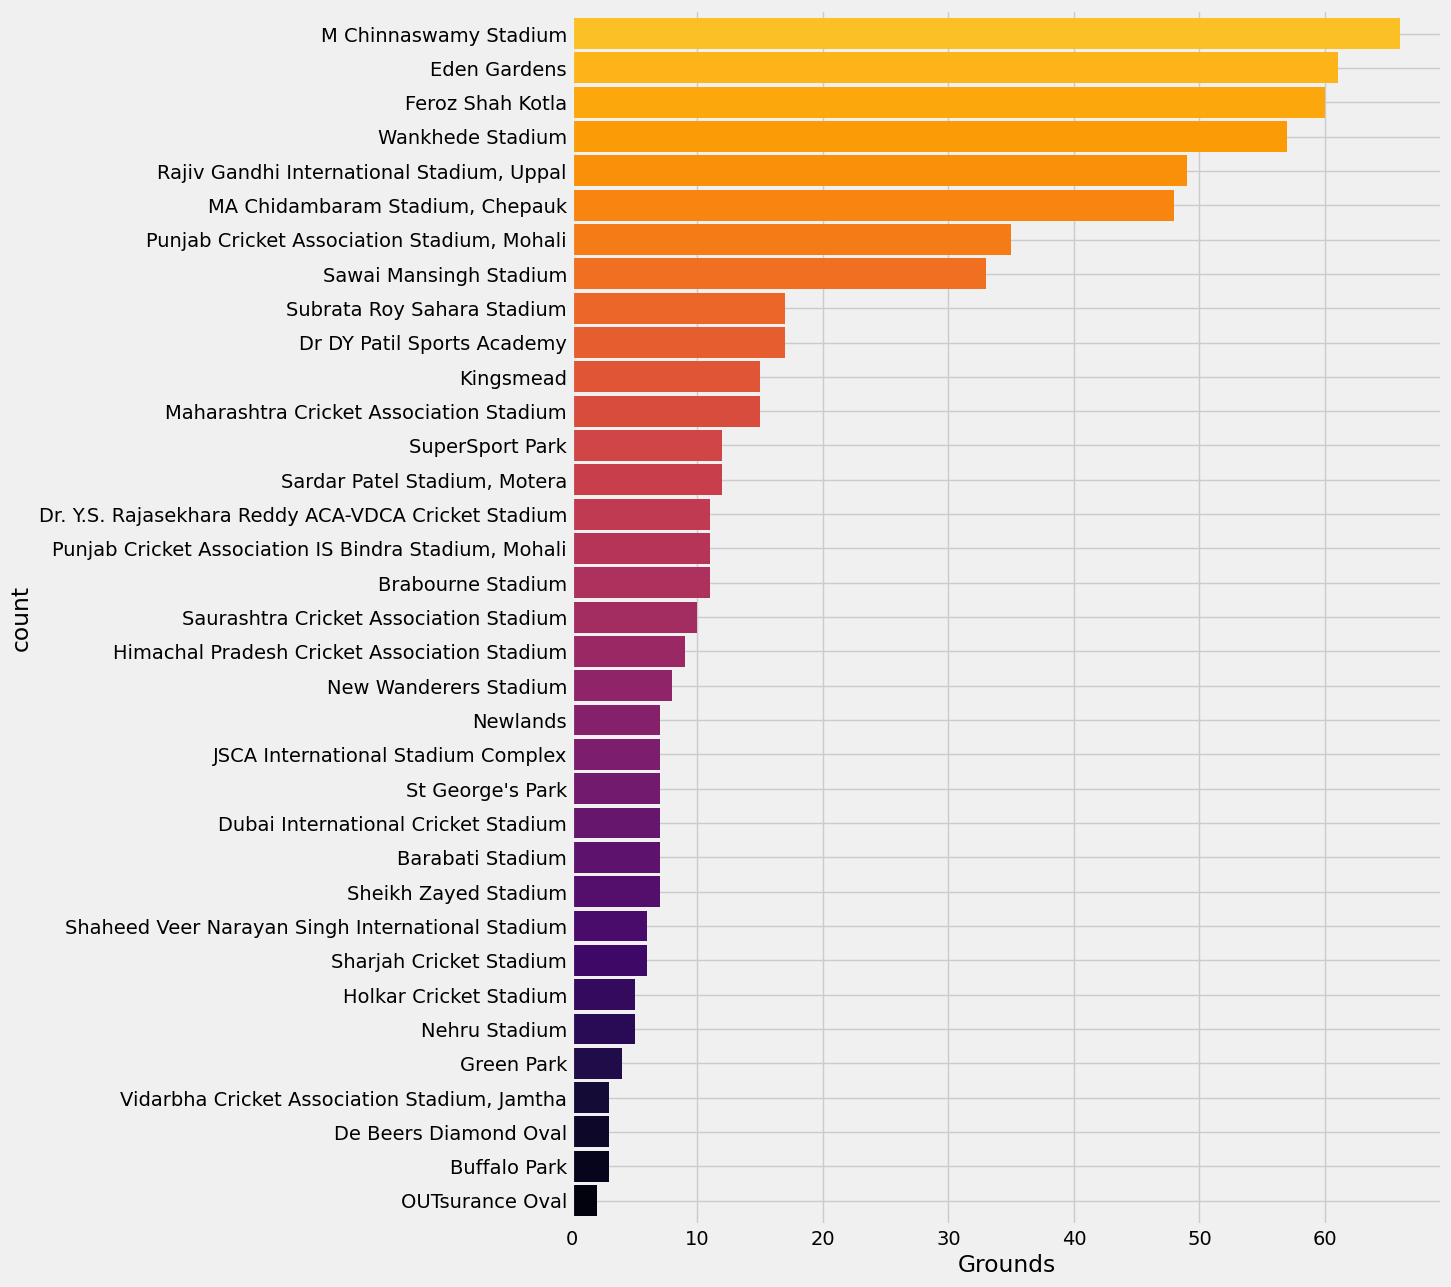

In [33]:
mlt.subplots(figsize=(10,15))
ax = matches['venue'].value_counts().sort_values(ascending=True).plot.barh(width=.9,color=sns.color_palette('inferno',40))
ax.set_xlabel('Grounds')
ax.set_ylabel('count')
mlt.show()

## Maximum Man Of Matches

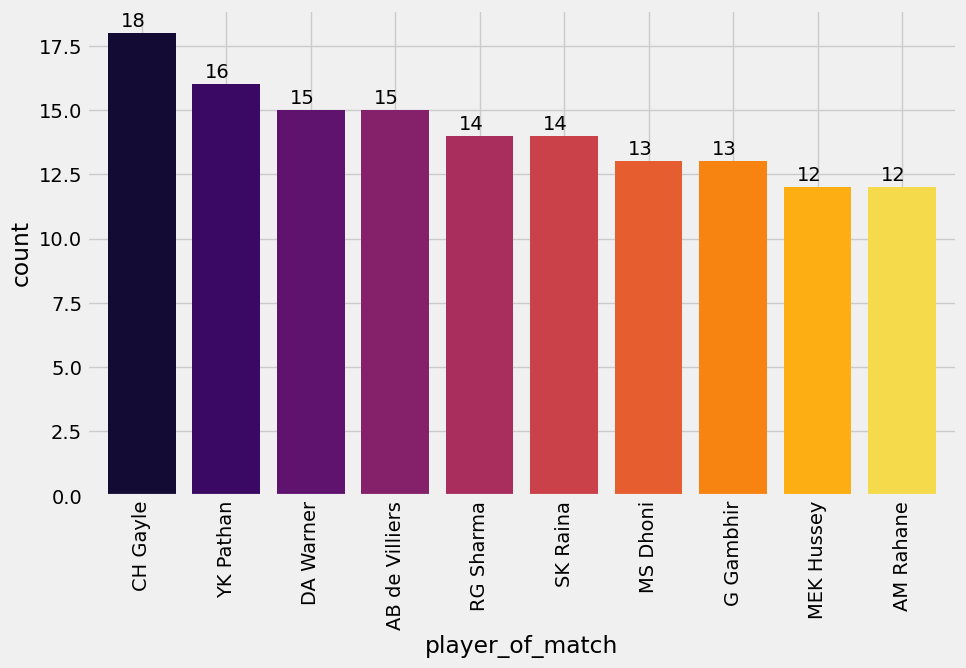

In [34]:
mlt.subplots(figsize=(10,6))
#the code used is very basic but gets the job done easily
ax = matches['player_of_match'].value_counts().head(10).plot.bar(width=.8, color=sns.color_palette('inferno',10))  #counts the values corresponding
# to each batsman and then filters out the top 10 batsman and then plots a bargraph
ax.set_xlabel('player_of_match')
ax.set_ylabel('count')
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x()+0.15, p.get_height()+0.25))
mlt.show()

## Winners by Year

In [35]:
print('Winners By Years')
for i in range(2008,2017):
    df=((matches[matches['season']==i]).iloc[-1])
    print(df[[1,10]].values)
#getting the last match in every season since the last match will be the final match for the season

Winners By Years
[np.int64(2008) 'RR']
[np.int64(2009) 'DC']
[np.int64(2010) 'CSK']
[np.int64(2011) 'CSK']
[np.int64(2012) 'KKR']
[np.int64(2013) 'MI']
[np.int64(2014) 'KKR']
[np.int64(2015) 'MI']
[np.int64(2016) 'SRH']


/tmp/ipykernel_2039/166353789.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



### Super Over!

In [36]:
print('\n Total Matches with Super Overs:',delivery[delivery['is_super_over']==1].match_id.nunique())


 Total Matches with Super Overs: 7


In [37]:
teams=['MI','KKR','RCB','DC','CSK','RR','DD','GL','KXIP','SRH','RPS','KTK','PW']
play=delivery[delivery['is_super_over']==1].batting_team.unique()
play=list(play)
print('Teams who haven"t ever played a super over are:' ,list(set(teams)-set(play)))

Teams who haven"t ever played a super over are: ['RPS', 'KTK', 'PW', 'DC']


### Favorite Umpires

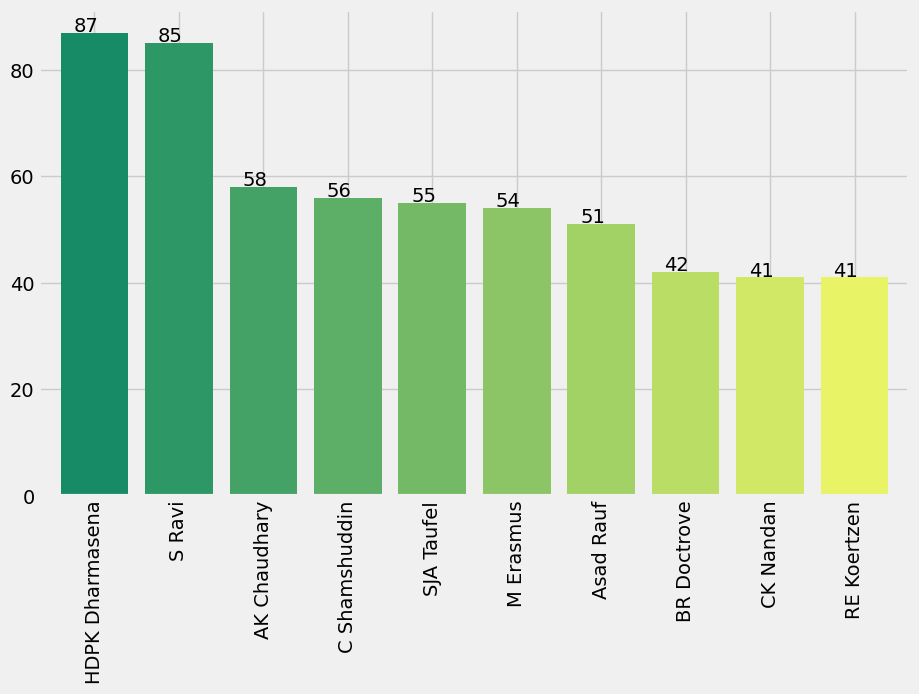

In [38]:
mlt.subplots(figsize=(10,6))
ump=pd.concat([matches['umpire1'],matches['umpire2']])
ax=ump.value_counts().head(10).plot.bar(width=0.8,color=sns.color_palette('summer',10))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x()+0.15, p.get_height()+0.25))
mlt.show()

## Team1 vs Team2

Here we will check the matches played between 2 teams and which had won more matches each year

### MI vs KKR

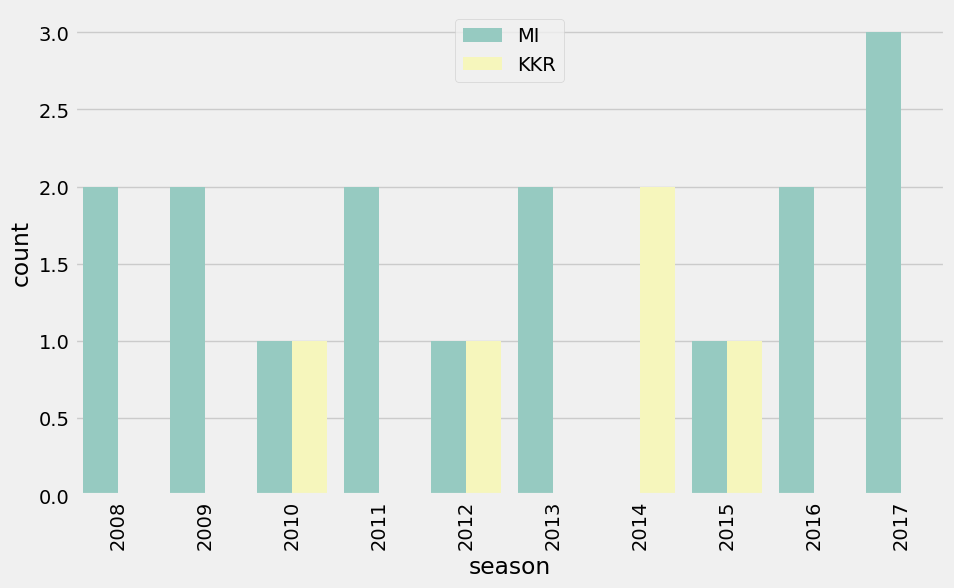

In [39]:
def team1_vs_team2(team1,team2):
    mt1=matches[((matches['team1']==team1)|(matches['team2']==team1))&((matches['team1']==team2)|(matches['team2']==team2))]
    sns.countplot(x='season', hue='winner',data=mt1,palette='Set3')
    mlt.xticks(rotation='vertical')
    leg = mlt.legend( loc = 'upper center')
    fig=mlt.gcf()
    fig.set_size_inches(10,6)
    mlt.show()
team1_vs_team2('KKR','MI')


MI have defeated KKR in 13 out of 18 matches played between them.Only in the year 2014, KKR won both the matches.Thus in a MI vs KKR match, we know on whom should we bet upon. Similar comparisions can be done between any two teams, we just need to change the team names.

One thing to notice is that MI and KKR have never played against each other in any qualifiers or finals as both of them have played only 2 matches every year, those being the group stage matches.

### MI vs CSK

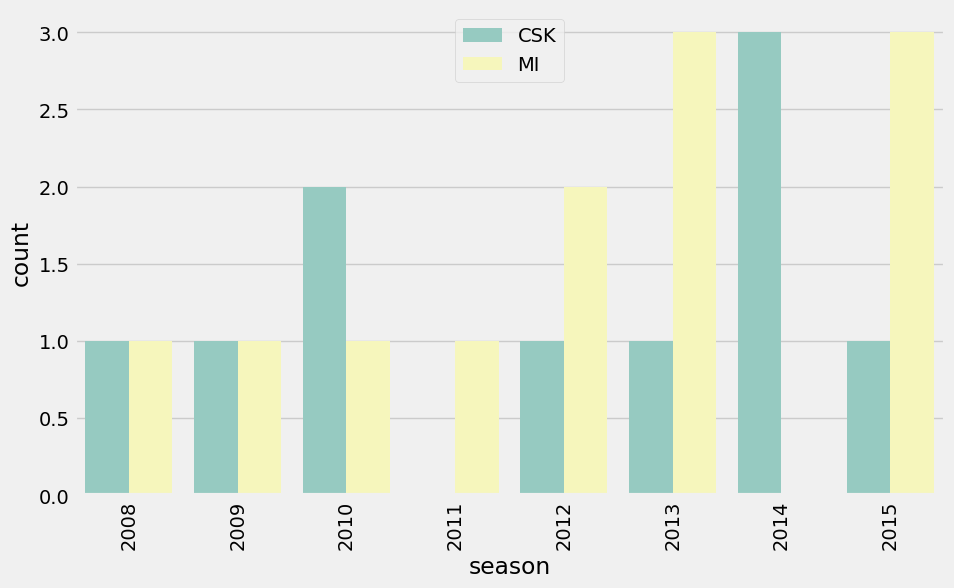

In [40]:
team1_vs_team2('CSK','MI')

Here se can see that MI and CSK have played against each other in more than 2 matches in some seasons i.e they have played qualifiers too.

## Matches Won By A Team Against Other Teams

Now we will be checking the number of times a Team has won against other teams. This will give us an idea as which team has an upper hand over the others when they play head-to-head.

In [41]:
def comparator(team1):
    teams=['MI','KKR','RCB','DC','CSK','RR','DD','GL','KXIP','SRH','RPS','KTK','PW']
    teams.remove(team1)
    opponents=teams.copy()
    mt1=matches[((matches['team1']==team1)|(matches['team2']==team1))]
    for i in opponents:
        mask = (((mt1['team1']==i)|(mt1['team2']==i)))&((mt1['team1']==team1)|(mt1['team2']==team1))
        mt2 = mt1.loc[mask, 'winner'].value_counts().to_frame().T
        print(mt2)

comparator('MI')

winner  MI  KKR
count   16    5
winner  MI  RCB
count   13    8
winner  MI  DC
count    6   4
winner  MI  CSK
count   12   10
winner  MI  RR
count   10   6
winner  MI  DD
count   11   9
winner  MI  GL
count    2   2
winner  MI  KXIP
count   10    10
winner  MI  SRH
count    5    5
winner  RPS  MI
count     4   2
winner  KTK
count     1
winner  MI  PW
count    5   1


### Score Distribution For Teams by Innings

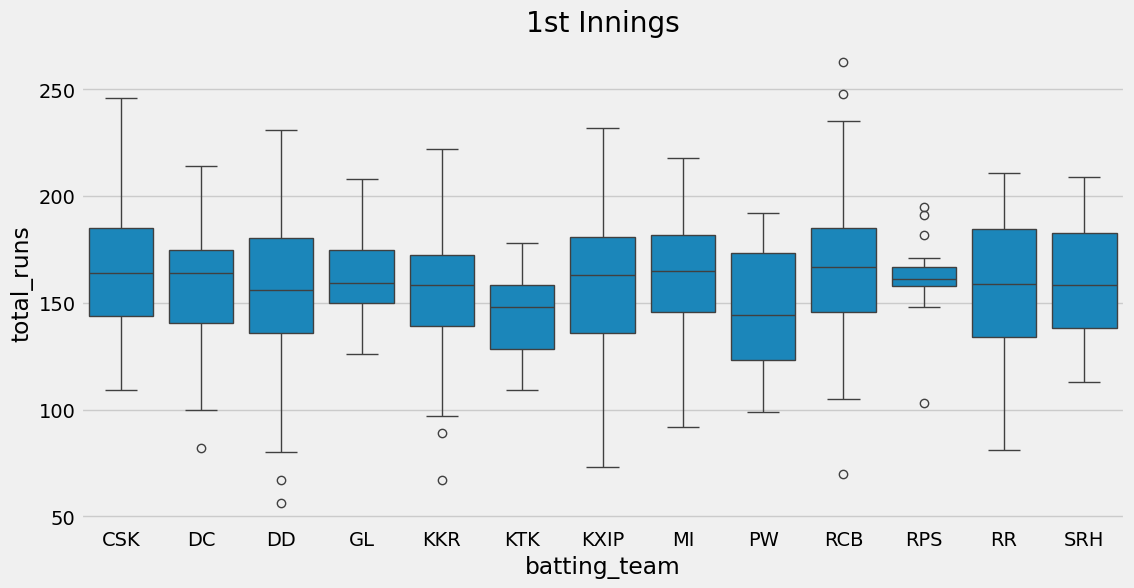

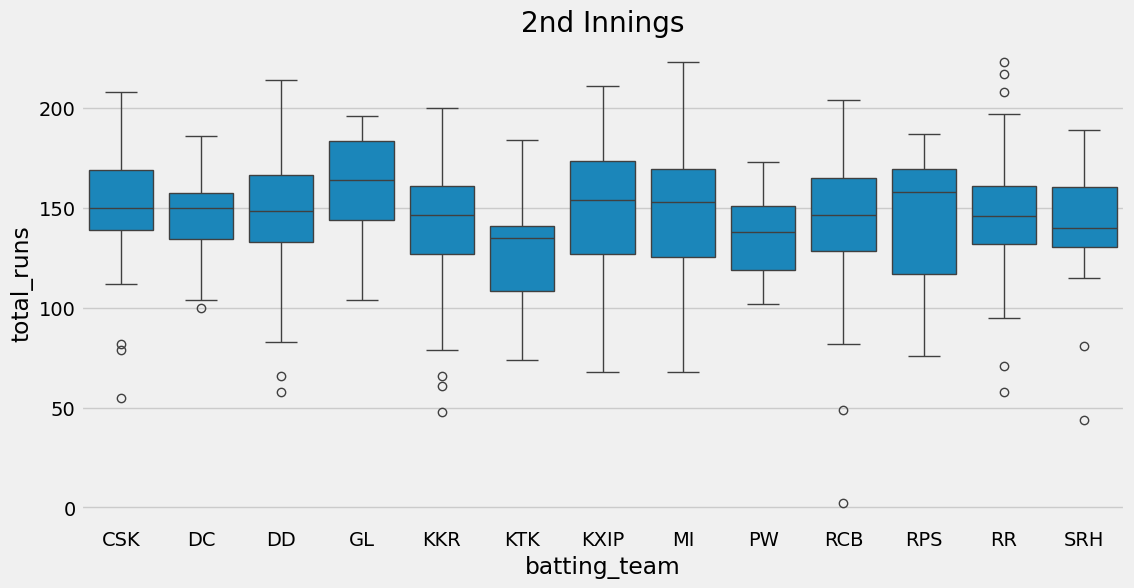

In [42]:
mlt.subplots(figsize=(12,6))
xyz=delivery.groupby(['match_id','inning','batting_team'])['total_runs'].sum().reset_index()
xyz.drop('match_id',axis=1,inplace=True)
xyz=xyz.sort_values(by=['batting_team','total_runs'],ascending=True)
score_1_inning=xyz[xyz['inning']==1]
score_2_inning=xyz[xyz['inning']==2]
sns.boxplot(x='batting_team',y='total_runs',data=score_1_inning).set_title('1st Innings')
mlt.show()
sns.boxplot(x='batting_team',y='total_runs',data=score_2_inning).set_title('2nd Innings')
fig=mlt.gcf()
fig.set_size_inches(12,6)

According to Graph 1 the batting by CSK in innings 1 looks to be the best.  Graph 2 also conveys the same story.

In Graph 2 we see a point near 0 which may seem to be outlier. But it is so because the match was disrupted.

## 200+ Scores

In [43]:
high_scores=delivery.groupby(['match_id', 'inning','batting_team','bowling_team'])['total_runs'].sum().reset_index()
#reset_index() converts the obtained series into a dataframe
high_scores=high_scores[high_scores['total_runs']>=200]
#nlargest is used to sort the given column
high_scores.nlargest(10,'total_runs')

,match_id,inning,batting_team,bowling_team,total_runs
829,411,1,RCB,PW,263
1250,620,1,RCB,GL,248
416,206,1,CSK,RR,246
122,61,1,CSK,KXIP,240
1134,562,1,RCB,MI,235
596,296,1,KXIP,RCB,232
522,259,1,DD,KXIP,231
981,486,1,KXIP,CSK,231
100,50,1,KXIP,MI,230
1170,580,1,RCB,SRH,227


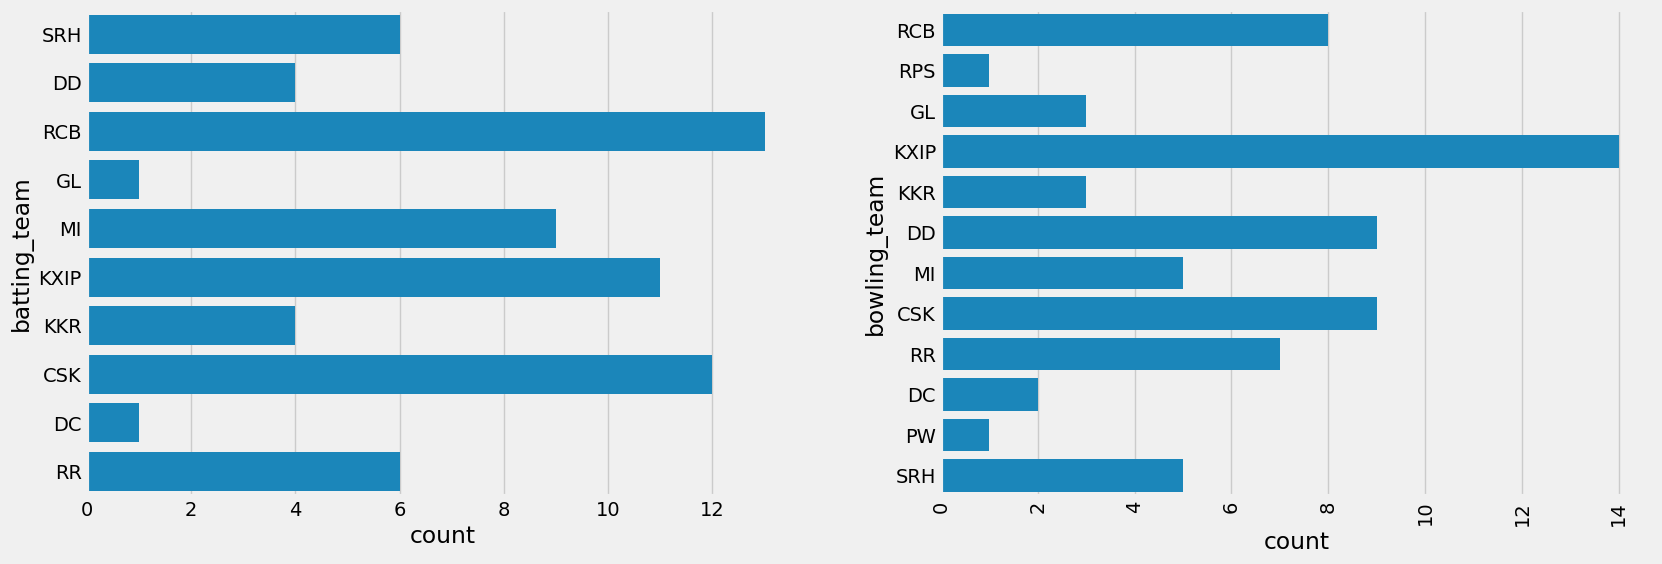

In [44]:
fig, ax =mlt.subplots(1,2)
sns.countplot(high_scores['batting_team'],ax=ax[0])
sns.countplot(high_scores['bowling_team'],ax=ax[1])
mlt.xticks(rotation=90)
fig=mlt.gcf()
fig.set_size_inches(18,6)
mlt.show()

The graph on the left shows the number of times a team has scored above 200 runs. The graph on the right shows the number of times a bowling team has conceeded above 200 runs.

In [45]:
print('Teams who have"nt ever scored 200 runs',list(set(teams)-set(high_scores['batting_team'])))
print('Teams who haven"t conceeded over 200 while bowling',list(set(teams)-set(high_scores['bowling_team'])))

Teams who have"nt ever scored 200 runs ['RPS', 'KTK', 'PW']
Teams who haven"t conceeded over 200 while bowling ['KTK']


In [46]:
high=delivery.groupby(['match_id', 'inning','batting_team','bowling_team'])['total_runs'].sum().reset_index()
high.set_index(['match_id'],inplace=True)
high['total_runs'].max()
high.columns
high=high.rename(columns={'total_runs':'count'})
high=high[high['count']>=200].groupby(['inning','batting_team','bowling_team']).count()
high

count
inning batting_team bowling_team       
1      CSK          DD                1
                    KKR               1
                    KXIP              2
                    MI                1
                    RCB               1
                    RR                1
                    SRH               2
       DC           RR                1
       DD           KXIP              1
                    MI                1
                    RPS               1
       GL           DD                1
       KKR          DC                1
                    KXIP              1
                    RCB               1
       KXIP         CSK               2
                    MI                1
                    RCB               2
                    RR                1
       MI           CSK               1
                    DD                4
                    RCB               1
                    RR                1
       RCB          CSK               1
                    DD                1
                    GL                2
                    KXIP              3
                    MI                1
                    PW                1
                    RR                1
                    SRH               1
       RR           CSK               1
                    DD                1
                    KXIP              1
       SRH          KKR               1
                    KXIP              2
                    RCB               2
                    RR                1
2      CSK          KXIP              1
                    RCB               1
                    RR                1
       DD           GL                1
       KKR          KXIP              1
       KXIP         CSK               2
                    DD                1
                    KKR               1
                    SRH               1
       MI           CSK               1
                    KXIP              1
       RCB          KXIP              1
                    SRH               1
       RR           CSK               1
                    DC                1
                    MI                1

The above dataframe shows the number of times a team has scored above 200 runs against another team. Clearly MI has scored 200+ againt DD 3 times and similarly RCB has scored 200+ againt KXIP 3 times. Also the number of 200+ runs are higher in the 1st innings.

In [47]:
high_scores=delivery.groupby(['match_id', 'inning','batting_team','bowling_team'])['total_runs'].sum().reset_index()
high_scores1=high_scores[high_scores['inning']==1]
high_scores2=high_scores[high_scores['inning']==2]
high_scores1=high_scores1.merge(high_scores2[['match_id','inning', 'total_runs']], on='match_id')
high_scores1.rename(columns={'inning_x':'inning_1','inning_y':'inning_2','total_runs_x':'inning1_runs','total_runs_y':'inning2_runs'},inplace=True)
high_scores1=high_scores1[high_scores1['inning1_runs']>=200]
high_scores1['is_score_chased']=1
high_scores1['is_score_chased'] = np.where(high_scores1['inning1_runs']<=high_scores1['inning2_runs'],
                                           'yes', 'no')
high_scores1.head()

,match_id,inning_1,batting_team,bowling_team,inning1_runs,inning_2,inning2_runs,is_score_chased
0,1,1,SRH,RCB,207,2,172,no
8,9,1,DD,RPS,205,2,108,no
19,20,1,RCB,GL,213,2,192,no
31,32,1,SRH,KXIP,207,2,181,no
35,36,1,SRH,KKR,209,2,161,no


### Chances of chasing 200+ target

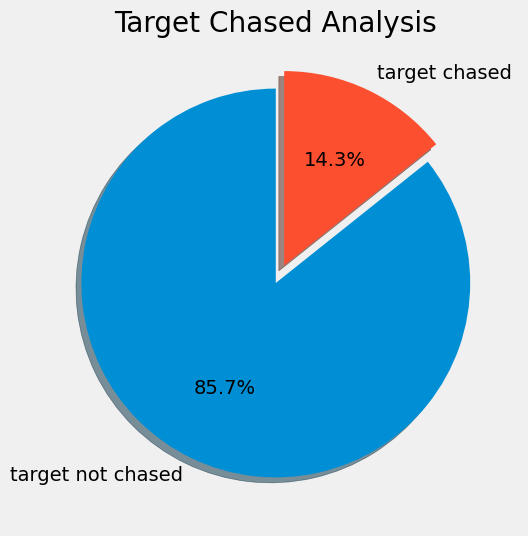

In [49]:
# Count chased vs not chased scores
slices = high_scores1['is_score_chased'].value_counts()

# Labels
labels = ['target not chased', 'target chased']

# Pie chart
mlt.figure(figsize=(6,6))

mlt.pie(
    slices,
    labels=labels,
    startangle=90,
    shadow=True,
    explode=(0, 0.1),
    autopct='%1.1f%%'
)

mlt.title('Target Chased Analysis')

mlt.show()

It seems to be clear that team batting first and scoring 200+ runs, has a very high probablity of winning the match.

## Batsman Comparator

I have created a function that compares 2 batsman based on their respective stats like runs or strike rate etc. First lets create a dataframe from where we will be taking all that values for comparison.

In [50]:
balls=delivery.groupby(['batsman'])['ball'].count().reset_index()
runs=delivery.groupby(['batsman'])['batsman_runs'].sum().reset_index()
balls=balls.merge(runs,left_on='batsman',right_on='batsman',how='outer')
balls.rename({'ball':'ball_x','batsman_runs':'ball_y'},axis=1,inplace=True)
sixes=delivery.groupby('batsman')['batsman_runs'].agg(lambda x: (x==4).sum()).reset_index()
fours=delivery.groupby(['batsman'])['batsman_runs'].agg(lambda x: (x==6).sum()).reset_index()
balls['strike_rate']=balls['ball_y']/balls['ball_x']*100
balls=balls.merge(sixes,left_on='batsman',right_on='batsman',how='outer')
balls=balls.merge(fours,left_on='batsman',right_on='batsman',how='outer')
compare=delivery.groupby(["match_id", "batsman","batting_team"])["batsman_runs"].sum().reset_index()
compare=compare.groupby(['batsman','batting_team'])['batsman_runs'].max().reset_index()
balls=balls.merge(compare,left_on='batsman',right_on='batsman',how='outer')
balls.rename({'ball_x':'balls','ball_y':'runs','batsman_runs_x':"6's",'batsman_runs_y':"4's",'batting_team':'Team','batsman_runs':'Highest_score'},axis=1,inplace=True)
balls.head()


,batsman,balls,runs,strike_rate,6's,4's,Team,Highest_score
0,A Ashish Reddy,196,280,142.857143,16,15,DC,10
1,A Ashish Reddy,196,280,142.857143,16,15,SRH,36
2,A Chandila,7,4,57.142857,0,0,RR,4
3,A Chopra,75,53,70.666667,7,0,KKR,24
4,A Choudhary,20,25,125.000000,1,1,RCB,15


Now using this dataframe, we can compare stats like the strike rate, or the number of 6's for 4's etc. We will be passing the names of 2 batsmen and two comparing measures for the comparision.

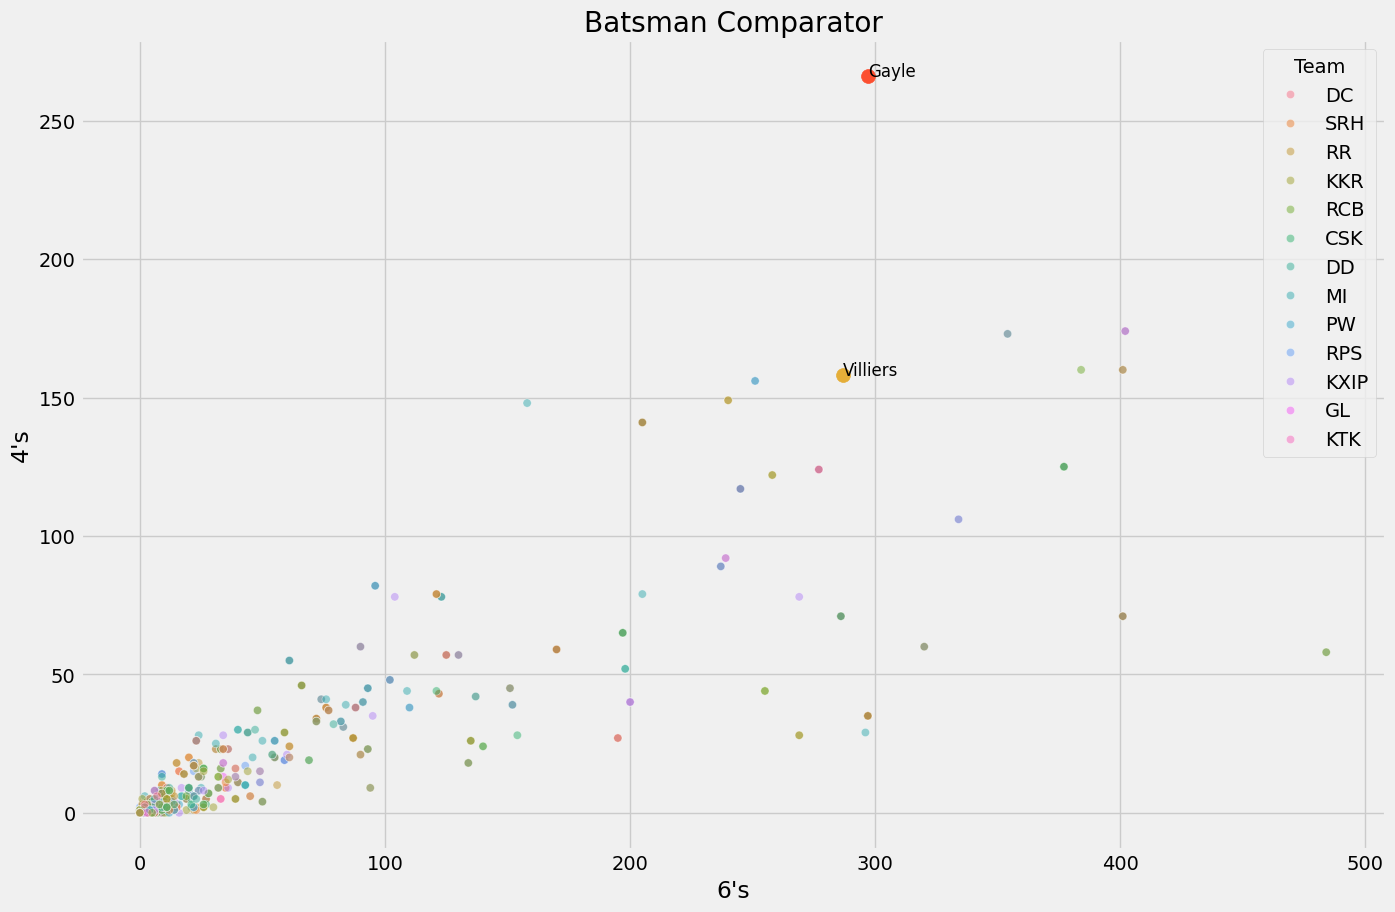

In [53]:
import matplotlib.pyplot as plt

def batsman_comparator(stat1, stat2, batsman1, batsman2):

    # Create plot
    plt.figure(figsize=(15,10))

    sns.scatterplot(
        data=balls,
        x=stat1,
        y=stat2,
        hue='Team',
        alpha=0.5
    )

    # Filter batsmen
    bats1 = balls[balls['batsman'].str.contains(batsman1, case=False, na=False)]

    bats2 = balls[balls['batsman'].str.contains(batsman2, case=False, na=False)]

    # Sort values
    bats1 = bats1.sort_values(by=stat1, ascending=False)

    bats2 = bats2.sort_values(by=stat1, ascending=False)

    # Plot batsman 1
    plt.scatter(
        bats1[stat1].values[0],
        bats1[stat2].values[0],
        s=100
    )

    plt.text(
        bats1[stat1].values[0],
        bats1[stat2].values[0],
        batsman1,
        fontsize=12
    )

    # Plot batsman 2
    plt.scatter(
        bats2[stat1].values[0],
        bats2[stat2].values[0],
        s=100
    )

    plt.text(
        bats2[stat1].values[0],
        bats2[stat2].values[0],
        batsman2,
        fontsize=12
    )

    plt.title('Batsman Comparator')

    plt.show()


# Compare batsmen
batsman_comparator("6's", "4's", 'Gayle', 'Villiers')

### Dhoni Vs Kohli

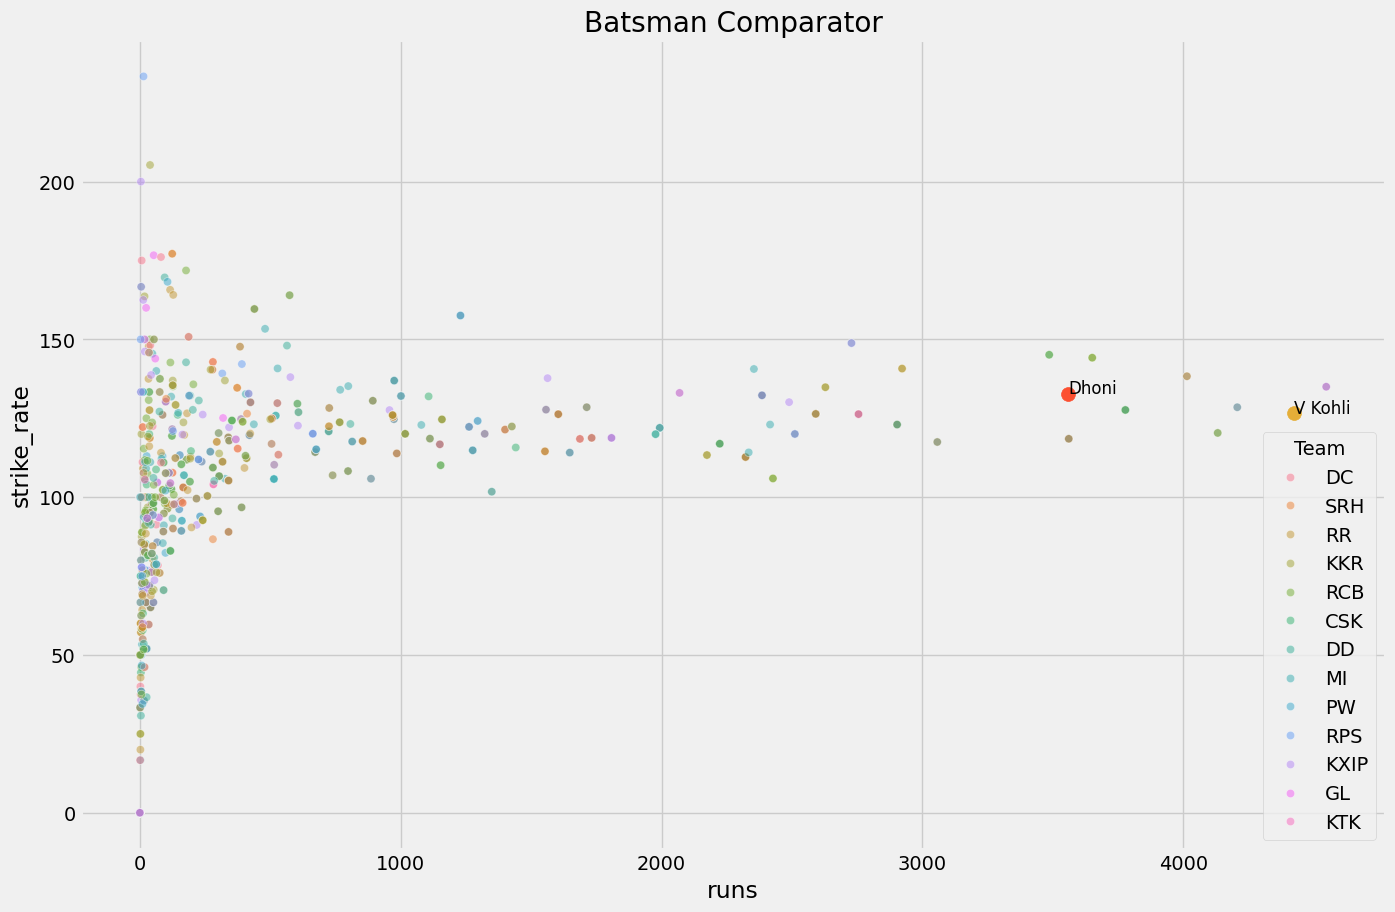

In [54]:
batsman_comparator("runs","strike_rate",'Dhoni','V Kohli')

## Top Batsmen

### Top 10 Batsman

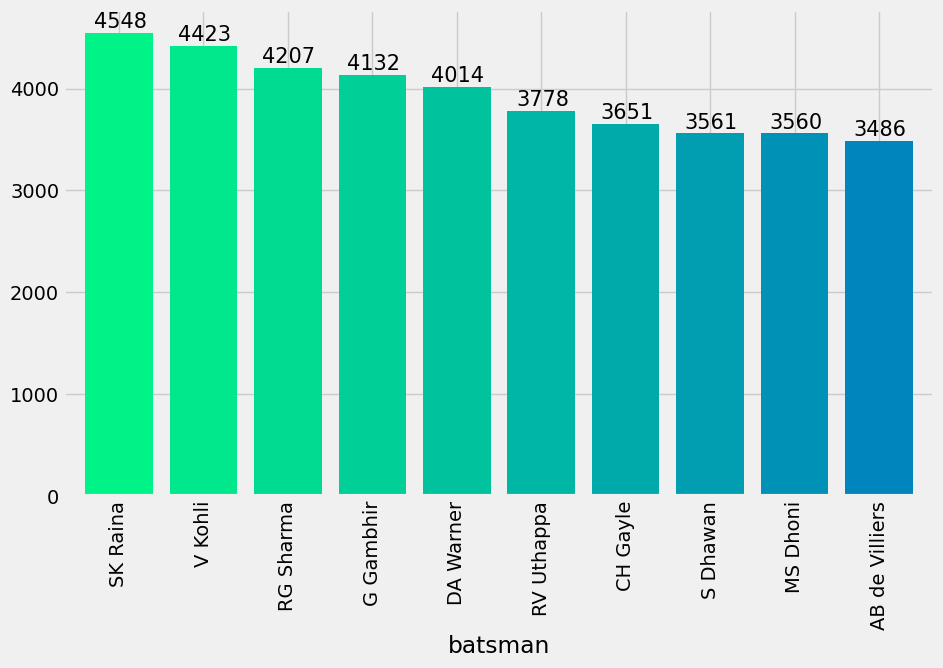

In [55]:
mlt.subplots(figsize=(10,6))
max_runs=delivery.groupby(['batsman'])['batsman_runs'].sum()
ax=max_runs.sort_values(ascending=False)[:10].plot.bar(width=0.8,color=sns.color_palette('winter_r',20))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x()+0.1, p.get_height()+50),fontsize=15)
mlt.show()

Virat Kohli has highest total runs across all seasons. Raina is just few runs behind with the second spot

### Top Batsman's with 1's, 2's, 3's, 4's

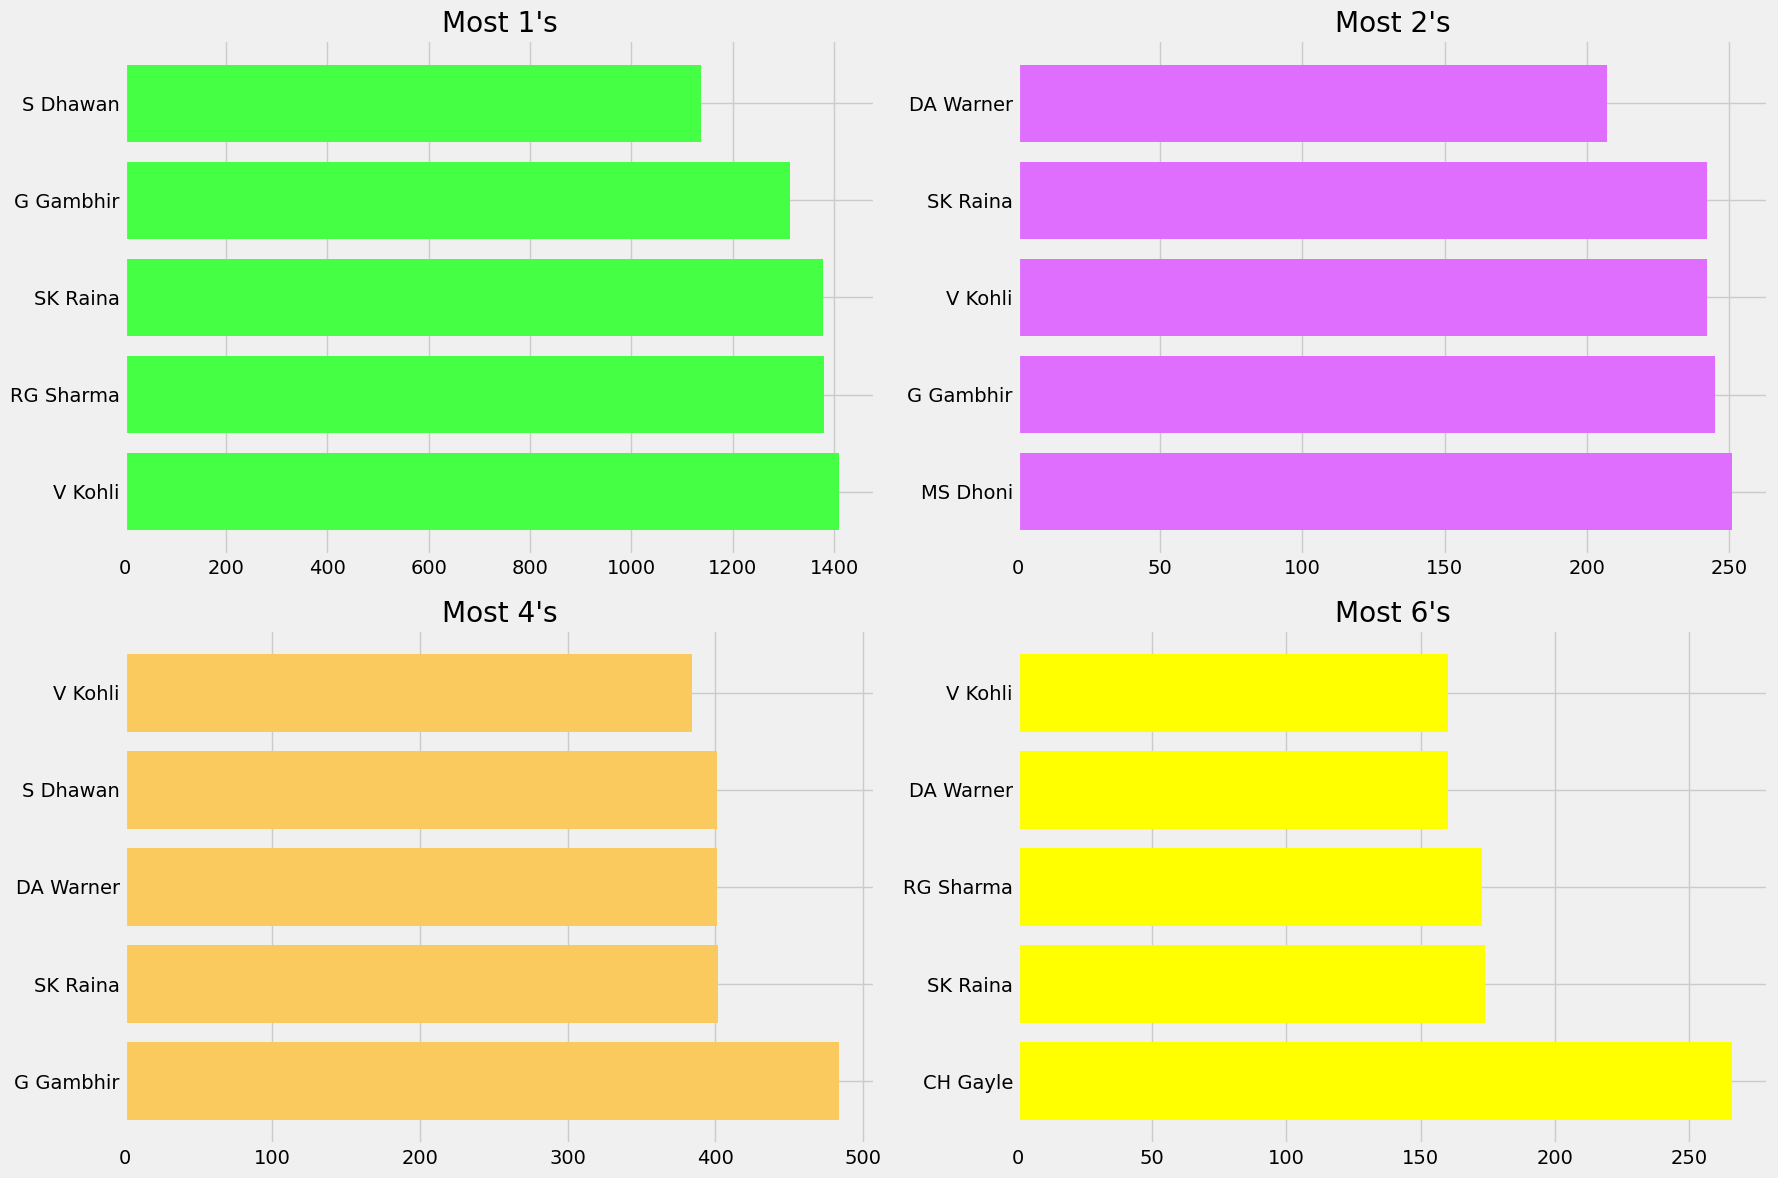

In [57]:
toppers = delivery.groupby(
    ['batsman', 'batsman_runs']
)['total_runs'].count().reset_index()

# Fixed pivot
toppers = toppers.pivot(
    index='batsman',
    columns='batsman_runs',
    values='total_runs'
)

fig, ax = mlt.subplots(2, 2, figsize=(18,12))

# Most 1's
toppers[1].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[0,0],
    color='#45ff45',
    width=0.8
)

ax[0,0].set_title("Most 1's")
ax[0,0].set_ylabel('')

# Most 2's
toppers[2].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[0,1],
    color='#df6dfd',
    width=0.8
)

ax[0,1].set_title("Most 2's")
ax[0,1].set_ylabel('')

# Most 4's
toppers[4].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[1,0],
    color='#fbca5f',
    width=0.8
)

ax[1,0].set_title("Most 4's")
ax[1,0].set_ylabel('')

# Most 6's
toppers[6].sort_values(ascending=False)[:5].plot(
    kind='barh',
    ax=ax[1,1],
    color='#ffff00',
    width=0.8
)

ax[1,1].set_title("Most 6's")
ax[1,1].set_ylabel('')

mlt.tight_layout()

mlt.show()

**Observations:**

 1. Kohli has scored the maximum 1's
 2. Dhoni has the maximum 2's . Those Strong Legs :p
 3. Gambhir has the maximum 4's.
 4. C Gayle has the maximum 6's  and he leads by a big margin.

### Top Individual Scores

In [58]:
top_scores = delivery.groupby(["match_id", "batsman","batting_team"])["batsman_runs"].sum().reset_index()
#top_scores=top_scores[top_scores['batsman_runs']>100]
top_scores.sort_values('batsman_runs', ascending=0).head(10)
top_scores.nlargest(10,'batsman_runs')

,match_id,batsman,batting_team,batsman_runs
6200,411,CH Gayle,RCB,175
900,60,BB McCullum,KKR,158
8426,562,AB de Villiers,RCB,133
9257,620,AB de Villiers,RCB,129
5585,372,CH Gayle,RCB,128
3135,206,M Vijay,CSK,127
529,36,DA Warner,SRH,126
7752,516,V Sehwag,KXIP,122
3686,243,PC Valthaty,KXIP,120
4223,279,V Sehwag,DD,119


Here too the Jamaican leads the table. Not only Gayle but there are many RCB players on the top scores list. Looks like RCB is a very formidable batting side.

### Individual Scores By Top Batsman each Inning

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

7.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

24.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

21.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

20.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categori

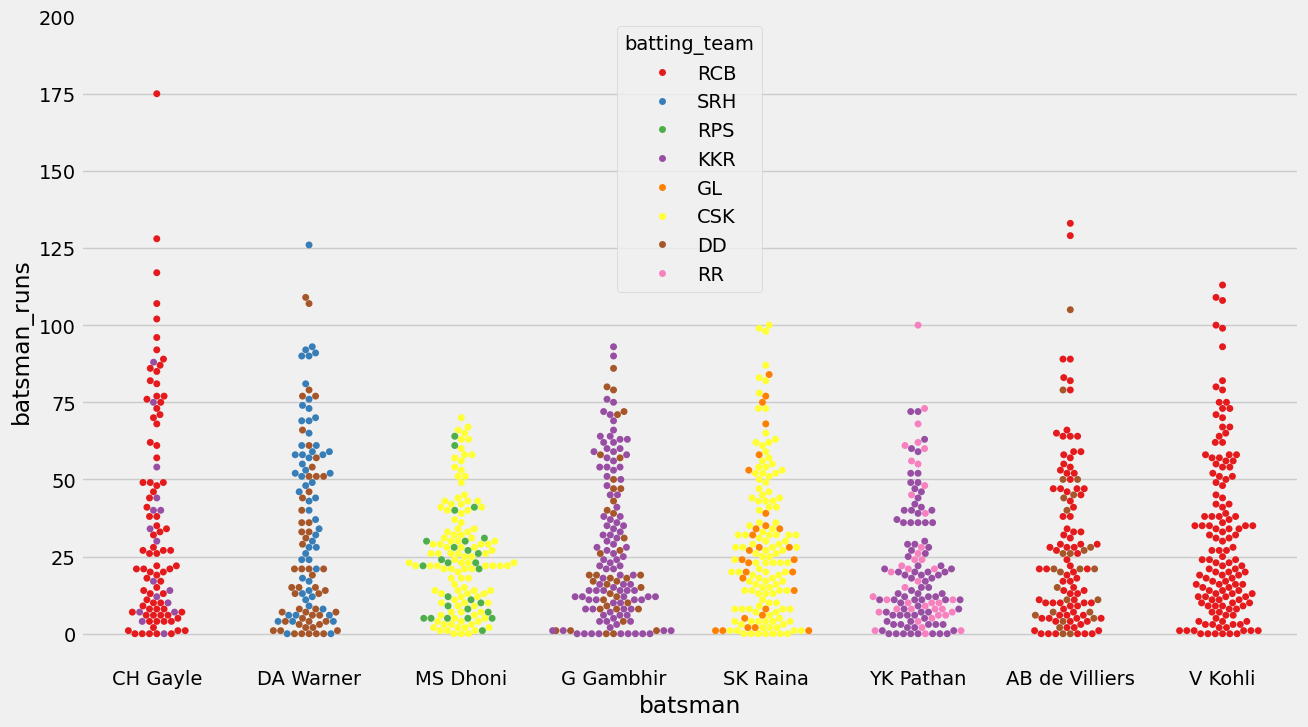

In [59]:
swarm=['CH Gayle','V Kohli','G Gambhir','SK Raina','YK Pathan','MS Dhoni','AB de Villiers','DA Warner']
scores = delivery.groupby(["match_id", "batsman","batting_team"])["batsman_runs"].sum().reset_index()
scores=scores[top_scores['batsman'].isin(swarm)]
sns.swarmplot(x='batsman',y='batsman_runs',data=scores,hue='batting_team',palette='Set1')
fig=mlt.gcf()
fig.set_size_inches(14,8)
mlt.ylim(-10,200)
mlt.show()

**Observations:**

 1. **Chris Gayle** has the highest Individual Score of **175** and Highest Number of Centuries i.e **5**
 2. **MS Dhoni** and **Gautam Gambhir** have never scored a Century.
 3. **V Kohli** has played only for 1 IPL Team in all seasons i.e RCB

### Runs Scored By Batsman Across Seasons

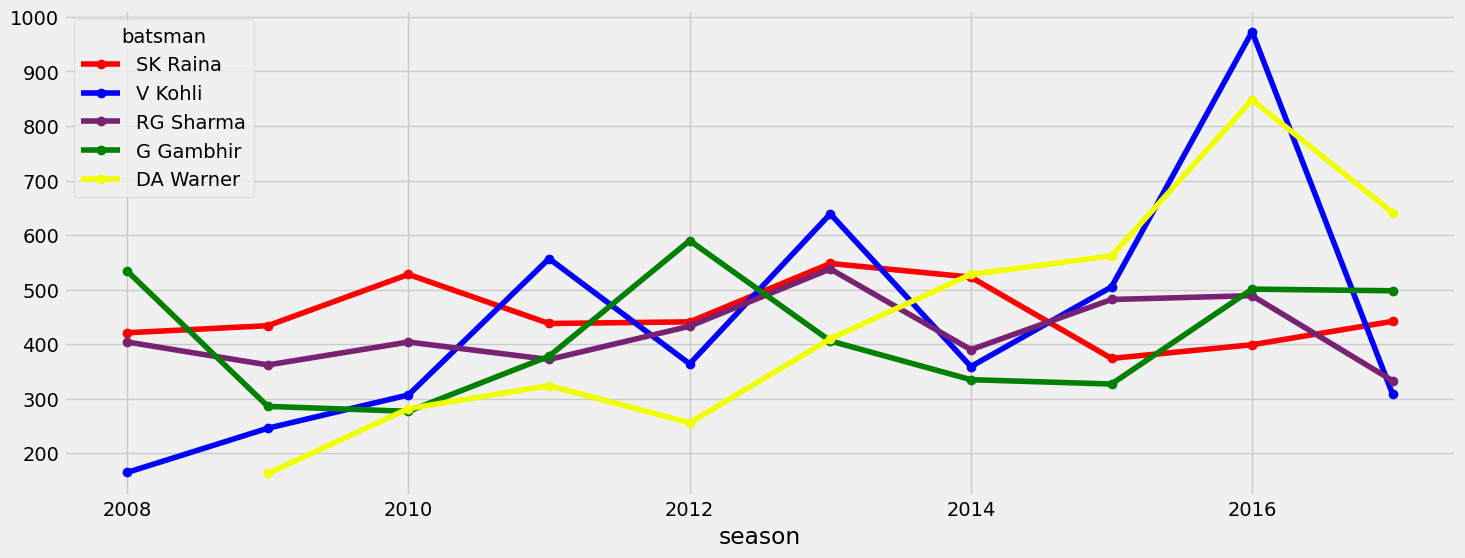

In [60]:
a=batsmen.groupby(['season','batsman'])['batsman_runs'].sum().reset_index()
a=a.groupby(['season','batsman'])['batsman_runs'].sum().unstack().T
a['Total']=a.sum(axis=1)
a=a.sort_values(by='Total',ascending=0)[:5]
a.drop('Total',axis=1,inplace=True)
a.T.plot(color=['red','blue','#772272','green','#f0ff00'],marker='o')
fig=mlt.gcf()
fig.set_size_inches(16,6)
mlt.show()

David Warner's form looks to be improving season by season. There has been a sharp decline in Kohli's Runs in the last season.

### How do the top batsmen score? (INTERACTIVE)

In [62]:
a = batsmen.groupby(
    ['batsman', 'batsman_runs']
)['total_runs'].count().reset_index()

b = max_runs.sort_values(ascending=False)[:10].reset_index()

c = b.merge(
    a,
    left_on='batsman',
    right_on='batsman',
    how='left'
)

# Remove unnecessary column
c.drop('batsman_runs_x', axis=1, inplace=True)

# Set batsman as index
c.set_index('batsman', inplace=True)

# Rename columns
c.columns = ['type', 'count']

# Keep only 1s,2s,4s,6s
c = c[
    (c['type'] == 1) |
    (c['type'] == 2) |
    (c['type'] == 4) |
    (c['type'] == 6)
]

# Reset index
c.reset_index(inplace=True)

# FIXED PIVOT
c = c.pivot(
    index='batsman',
    columns='type',
    values='count'
)

# Replace NaN with 0
c.fillna(0, inplace=True)

# =========================
# PLOTLY GRAPH
# =========================

trace1 = go.Bar(
    y=c.index,
    x=c[6],
    name="6's",
    orientation='h',
    marker=dict(
        color='rgba(178, 78, 139, 0.6)',
        line=dict(
            color='rgba(178, 78, 139, 1.0)',
            width=3
        )
    )
)

trace2 = go.Bar(
    y=c.index,
    x=c[4],
    name="4's",
    orientation='h',
    marker=dict(
        color='rgba(58, 71, 80, 0.6)',
        line=dict(
            color='rgba(58, 71, 80, 1.0)',
            width=3
        )
    )
)

trace3 = go.Bar(
    y=c.index,
    x=c[2],
    name="2's",
    orientation='h',
    marker=dict(
        color='rgba(101, 178, 139, 0.6)',
        line=dict(
            color='rgba(101, 178, 139, 1.0)',
            width=3
        )
    )
)

trace4 = go.Bar(
    y=c.index,
    x=c[1],
    name="1's",
    orientation='h',
    marker=dict(
        color='rgba(208, 105, 80, 0.6)',
        line=dict(
            color='rgba(208, 105, 80, 1.0)',
            width=3
        )
    )
)

data = [trace1, trace2, trace3, trace4]

layout = go.Layout(
    title='How Top Batsmen Score',
    barmode='stack'
)

fig = go.Figure(data=data, layout=layout)

py.iplot(fig)

### Frequency of Scores

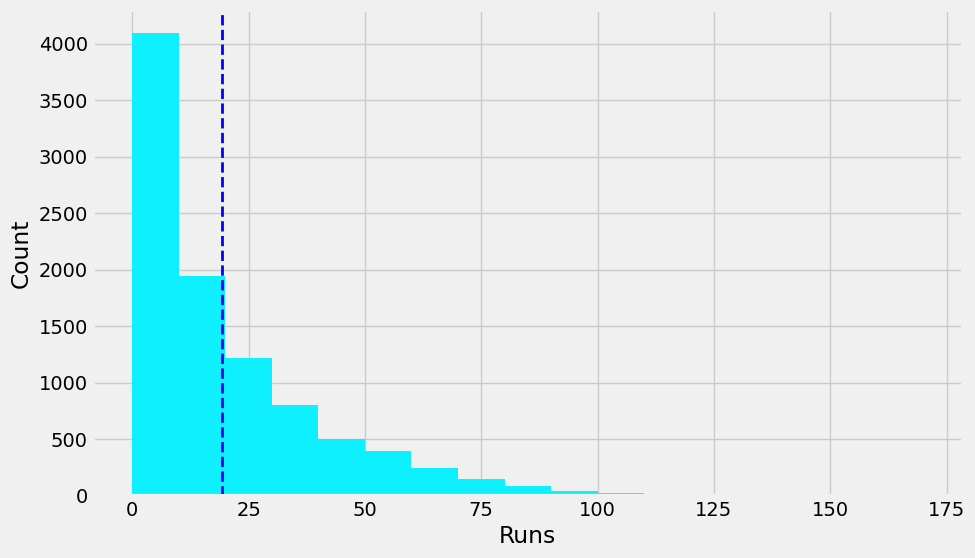

In [63]:
mlt.subplots(figsize=(10,6))
bins=range(0,180,10)
mlt.hist(top_scores["batsman_runs"],bins,histtype="bar",rwidth=1.2,color='#0ff0ff')
mlt.xlabel('Runs')
mlt.ylabel('Count')
mlt.axvline(top_scores["batsman_runs"].mean(), color='b', linestyle='dashed', linewidth=2)
mlt.plot()
mlt.show()

The average score for a batsman is around 19-20. Also the number of single digit score is quite high and the number of centuries is low.

### Orange Caps Each Season(Highest Run Getter per Season) (INTERACTIVE)

In [64]:
orange=matches[['id','season']]
orange=orange.merge(delivery,left_on='id',right_on='match_id',how='left')
orange=orange.groupby(['season','batsman'])['batsman_runs'].sum().reset_index()
orange=orange.sort_values('batsman_runs',ascending=0)
orange=orange.drop_duplicates(subset=["season"],keep="first")
orange.sort_values(by='season')

trace1 = go.Bar(
    x=orange['season'].values,
    y=orange['batsman_runs'].values,
    name='Total Matches',
    text=orange['batsman'].values,
    marker=dict(
        color='rgb(255,140,0)',
        line=dict(
            color='rgb(8,48,107)',
            width=1.5,
        )
    ),
    opacity=1
)


layout = go.Layout(
    title='Orange-Cap Holders',
)
data=[trace1]
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

## Top Bowlers

### Highest Wicket Taker

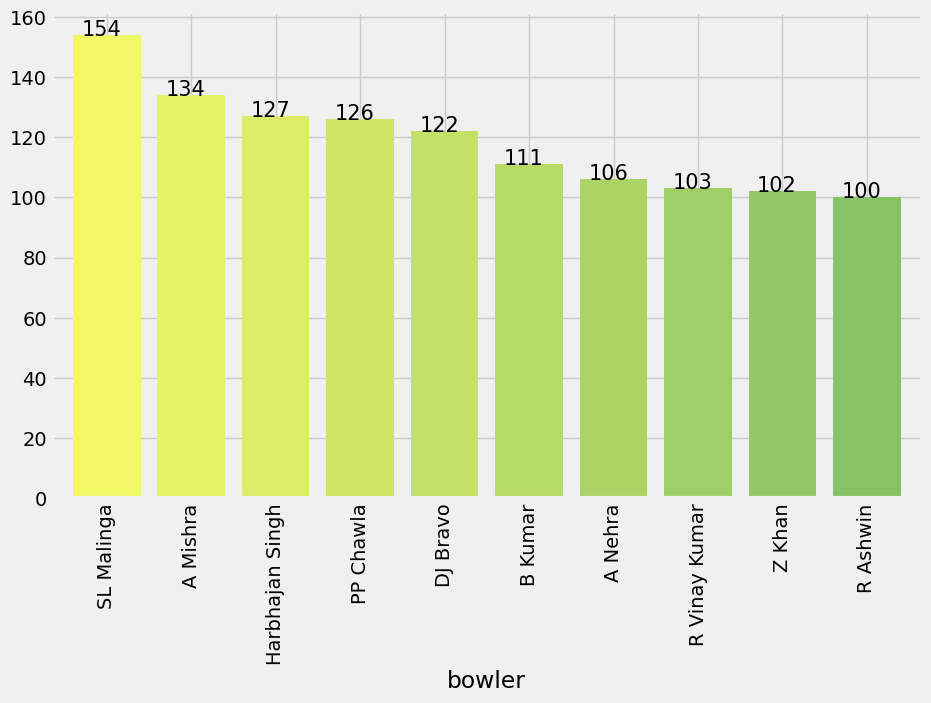

In [65]:
mlt.subplots(figsize=(10,6))
dismissal_kinds = ["bowled", "caught", "lbw", "stumped", "caught and bowled", "hit wicket"]  #since run-out is not creditted to the bowler
ct=delivery[delivery["dismissal_kind"].isin(dismissal_kinds)]
ax=ct['bowler'].value_counts()[:10].plot.bar(width=0.8,color=sns.color_palette('summer_r',20))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x()+0.10, p.get_height()),fontsize=15)
mlt.show()

Lasith Malinga leads the chart, thanks to his unpredictable bowling action. Other bowlers have a very small wicket margin between them.

### Maximum Overs

In [67]:
# Create dataframe with total balls bowled
eco = delivery.groupby('bowler').size().reset_index(name='total_balls')

# Convert balls to overs
eco['overs'] = eco['total_balls'] // 6

# Bowlers with more than 200 overs
result = eco[eco['overs'] > 200] \
    .sort_values(by='overs', ascending=False)[['bowler', 'overs']] \
    .head(5)

print(result)

              bowler  overs
117  Harbhajan Singh    498
5           A Mishra    450
294       SL Malinga    449
218          P Kumar    439
229        PP Chawla    432


Most Economical Bowlers with 300+ overs

In [69]:
# Total runs conceded by each bowler
runs = delivery.groupby('bowler')['total_runs'].sum().reset_index()

# Total balls bowled
balls = delivery.groupby('bowler').size().reset_index(name='total_balls')

# Merge both
eco = runs.merge(balls, on='bowler')

# Convert balls to overs
eco['overs'] = eco['total_balls'] / 6

# Economy rate
eco['economy'] = eco['total_runs'] / eco['overs']

# Bowlers with more than 300 overs
result = eco[eco['overs'] > 300] \
    .sort_values('economy') \
    [['bowler', 'economy']] \
    .head(10)

print(result)

              bowler   economy
300        SP Narine  6.395706
234         R Ashwin  6.490886
103         DW Steyn  6.600278
294       SL Malinga  6.757238
117  Harbhajan Singh  6.931415
50           B Kumar  7.039922
5           A Mishra  7.336293
230          PP Ojha  7.400514
355           Z Khan  7.539543
218          P Kumar  7.604096


### Top 20 Bowlers (INTERACTIVE)

In [71]:
# Total runs given by each bowler
bowlers = delivery.groupby('bowler')['total_runs'].sum().reset_index()

# Total balls bowled
bowl = delivery['bowler'].value_counts().reset_index()
bowl.columns = ['bowler', 'balls']

# Merge balls data
bowlers = bowlers.merge(bowl, on='bowler', how='left')

# Rename columns
bowlers.rename(columns={'total_runs': 'runs_given'}, inplace=True)

# Calculate overs
bowlers['overs'] = bowlers['balls'] / 6

# Dismissal types counted as wickets
dismissal_kinds = [
    "bowled",
    "caught",
    "lbw",
    "stumped",
    "caught and bowled",
    "hit wicket"
]

# Filter wickets
ct = delivery[delivery["dismissal_kind"].isin(dismissal_kinds)]

# Count wickets per bowler
ct = ct['bowler'].value_counts().reset_index()
ct.columns = ['bowler', 'wickets']

# Merge wicket data
bowlers = bowlers.merge(ct, on='bowler', how='left')

# Fill missing wickets with 0
bowlers['wickets'] = bowlers['wickets'].fillna(0)

# Economy rate
bowlers['economy'] = bowlers['runs_given'] / bowlers['overs']

# Show output
bowlers.head()

,bowler,runs_given,balls,overs,wickets,economy
0,A Ashish Reddy,400,270,45.000000,18.0,8.888889
1,A Chandila,245,234,39.000000,11.0,6.282051
2,A Choudhary,144,108,18.000000,5.0,8.000000
3,A Flintoff,106,66,11.000000,2.0,9.636364
4,A Kumble,1089,983,163.833333,45.0,6.646999


In [72]:
trace = go.Scatter(
    y = bowlers['wickets'],
    x = bowlers['bowler'],
    mode='markers',
    marker=dict(
        size= bowlers['wickets'].values,
        color = bowlers['economy'].values,
        colorscale='Viridis',
        showscale=True,
        colorbar = dict(title = 'Economy'),
    ),
    text = bowlers['overs'].values
)
data = [(trace)]

layout= go.Layout(
    autosize= True,
    title= 'Top 20 Wicket Taking Bowlers',
    hovermode= 'closest',
    xaxis=dict(
        showgrid=False,
        zeroline=False,
        showline=False,
        title='Bowlers'
    ),
    yaxis=dict(
        title= 'Wickets Taken',
        ticklen= 5,
        gridwidth= 2,
        showgrid=False,
        zeroline=False,
        showline=False
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatterChol')

### Highest Dismissals for a Batsman by a Bowler

In [74]:
dismissal_list = [
    'caught',
    'lbw',
    'bowled',
    'stumped',
    'caught and bowled',
    'hit wicket'
]

# Function to get highest dismissing bowler
def get_top_bowler(batsman_name):

    temp = delivery[delivery['batsman'] == batsman_name]

    temp = temp[temp['dismissal_kind'].isin(dismissal_list)]

    temp = (
        temp.groupby('bowler')['dismissal_kind']
        .count()
        .sort_values(ascending=False)
        .head(1)
        .reset_index()
    )

    temp['batsman'] = batsman_name

    return temp


# Generate dataframes
gayle = get_top_bowler('CH Gayle')
kohli = get_top_bowler('V Kohli')
raina = get_top_bowler('SK Raina')
abd = get_top_bowler('AB de Villiers')
msd = get_top_bowler('MS Dhoni')
gg = get_top_bowler('G Gambhir')
rohit = get_top_bowler('RG Sharma')
uthapa = get_top_bowler('RV Uthappa')
dhawan = get_top_bowler('S Dhawan')
warn = get_top_bowler('DA Warner')

# Combine all dataframes
new = pd.concat(
    [gayle, kohli, raina, abd, msd, gg, rohit, uthapa, dhawan, warn],
    ignore_index=True
)

# Select required columns
new = new[['batsman', 'bowler', 'dismissal_kind']]

# Rename columns
new.columns = ['batsman', 'bowler', 'No_of_Dismissals']

# Show result
new

,batsman,bowler,No_of_Dismissals
0,CH Gayle,Sandeep Sharma,4
1,V Kohli,A Nehra,6
2,SK Raina,Harbhajan Singh,5
3,AB de Villiers,KH Pandya,4
4,MS Dhoni,Z Khan,7
5,G Gambhir,Z Khan,6
6,RG Sharma,R Vinay Kumar,6
7,RV Uthappa,A Mishra,4
8,S Dhawan,Z Khan,4
9,DA Warner,UT Yadav,3


### Frequency Of Economy

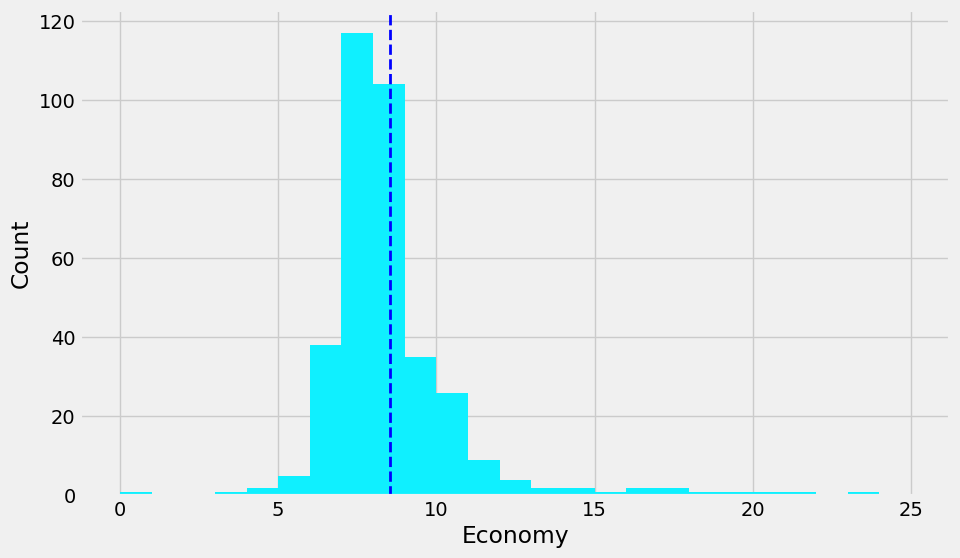

In [75]:
mlt.subplots(figsize=(10,6))
eco.replace([np.inf, -np.inf], np.nan,inplace=True)
eco.fillna(0,inplace=True)
bins=range(0,26)
mlt.hist(eco['economy'],bins,histtype="bar",rwidth=1.2,color='#0ff0ff')
mlt.xlabel('Economy')
mlt.ylabel('Count')
mlt.axvline(eco["economy"].mean(), color='b', linestyle='dashed', linewidth=2)
mlt.plot()
mlt.show()

The average economy rate is between 8.5-9

### Purple Caps Each Season (Maximum Wickets By Bowler per Season) (INTERACTIVE)

In [76]:
dismissal_kinds = ["bowled", "caught", "lbw", "stumped", "caught and bowled", "hit wicket"]  #since run-out is not creditted to the bowler
purple=delivery[delivery["dismissal_kind"].isin(dismissal_kinds)]
purple=purple.merge(matches,left_on='match_id',right_on='id',how='outer')
purple=purple.groupby(['season','bowler'])['dismissal_kind'].count().reset_index()
purple=purple.sort_values('dismissal_kind',ascending=False)
purple=purple.drop_duplicates('season',keep='first').sort_values(by='season')
purple.rename({'dismissal_kind':'count_wickets'},axis=1,inplace=True)

trace1 = go.Bar(
    x=purple['season'].values,
    y=purple['count_wickets'].values,
    name='Total Matches',
    text=purple['bowler'].values,
    marker=dict(
        color='rgb(75,0,130)',
        line=dict(
            color='rgb(108,148,107)',
            width=1.5,
        )
    ),
    opacity=1
)


layout = go.Layout(
    title='Purple-Cap Holders',
)
data=[trace1]
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

### Extras And Wickets (INTERACTIVE)

In [80]:
# Initialize Plotly properly for Colab
import plotly
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)

# Extras data
extras = ['wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs']
sizes = [5161, 680, 3056, 612]

# Dismissal types
dismiss = [
    "run out",
    "bowled",
    "caught",
    "lbw",
    "stumped",
    "caught and bowled",
    "hit wicket"
]

# Filter wickets
ct = delivery[delivery["dismissal_kind"].isin(dismiss)]

# Count wicket types
bx = ct.dismissal_kind.value_counts()[:10]

# Create donut charts
fig = {
    "data": [

        # Extras chart
        {
            "values": sizes,
            "labels": extras,
            "domain": {"x": [0, 0.48]},
            "name": "Extras",
            "hoverinfo": "label+percent+name",
            "hole": 0.4,
            "type": "pie"
        },

        # Wickets chart
        {
            "values": bx.values,
            "labels": bx.index,
            "textposition": "inside",
            "domain": {"x": [0.54, 1]},
            "name": "Wickets",
            "hoverinfo": "label+percent+name",
            "hole": 0.4,
            "type": "pie"
        }
    ],

    "layout": {

        "title": "Extras Distribution and Types Of Wickets",

        "annotations": [

            {
                "font": {"size": 15},
                "showarrow": False,
                "text": "EXTRAS",
                "x": 0.18,
                "y": 0.5
            },

            {
                "font": {"size": 15},
                "showarrow": False,
                "text": "WICKETS",
                "x": 0.85,
                "y": 0.5
            }
        ]
    }
}

# Convert to Plotly figure
fig = go.Figure(fig)

# Display plot
fig.show()

## Teams with maximum Boundaries (INTERACTIVE)

In [82]:
# Count total 6's by team
ax = (
    delivery[delivery['batsman_runs'] == 6]
    ['batting_team']
    .value_counts()
    .reset_index()
)

ax.columns = ['team', "6's"]

# Count total 4's by team
ax2 = (
    delivery[delivery['batsman_runs'] == 4]
    ['batting_team']
    .value_counts()
    .reset_index()
)

ax2.columns = ['team', "4's"]

# Merge both dataframes
ax = ax.merge(ax2, on='team', how='left')

# Plot 6's
trace1 = go.Bar(
    x=ax['team'],
    y=ax["6's"],
    name="6's",

    marker=dict(
        color='rgba(204,12,28,0.6)',
        line=dict(
            color='rgba(204,12,28,1.0)',
            width=2
        )
    )
)

# Plot 4's
trace2 = go.Bar(
    x=ax['team'],
    y=ax["4's"],
    name="4's",

    marker=dict(
        color='rgba(9,234,227,0.6)',
        line=dict(
            color='rgba(9,227,227,1.0)',
            width=2
        )
    )
)

# Combine traces
data = [trace1, trace2]

# Layout
layout = go.Layout(
    title="Teams with Maximum Boundaries",
    barmode='stack',
    xaxis=dict(title='Teams'),
    yaxis=dict(title='Count')
)

# Create figure
fig = go.Figure(data=data, layout=layout)

# Show plot
fig.show()

RCB-RCB everywhere. Here too RCB leads with a big margin

## How to win Finals??

First let us see which teams have played and won the maximum finals

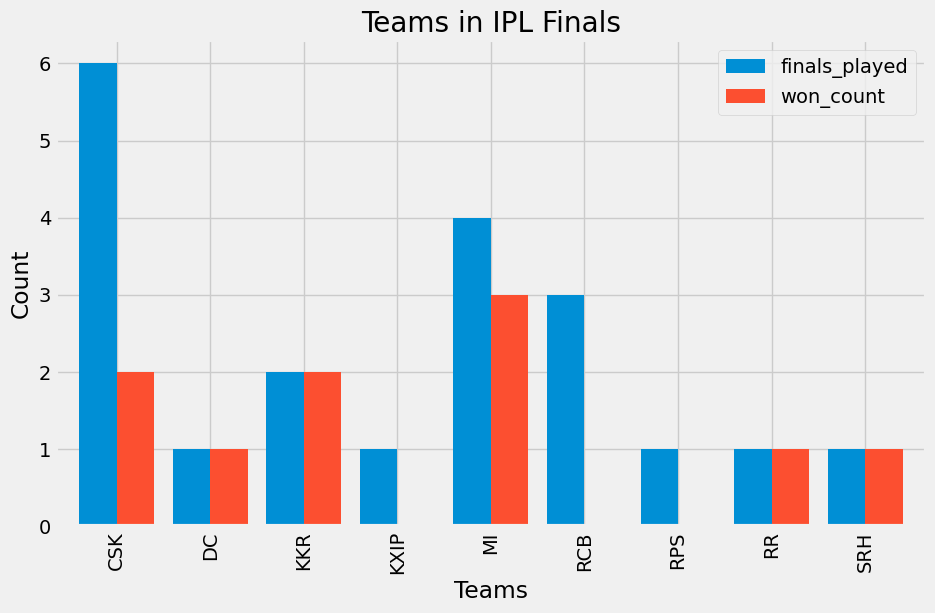

In [84]:
# Get only IPL final matches (last match of every season)
finals = matches.drop_duplicates(subset=['season'], keep='last')

# Select useful columns
finals = finals[
    ['id', 'season', 'city', 'team1', 'team2',
     'toss_winner', 'toss_decision', 'winner']
]

# Count finals played by each team
most_finals = pd.concat([
    finals['team1'],
    finals['team2']
]).value_counts().reset_index()

# Rename columns properly
most_finals.columns = ['team', 'finals_played']

# Count finals won
xyz = finals['winner'].value_counts().reset_index()
xyz.columns = ['team', 'won_count']

# Merge both dataframes
most_finals = most_finals.merge(
    xyz,
    on='team',
    how='outer'
)

# Replace NaN with 0
most_finals = most_finals.fillna(0)

# Set team as index
most_finals.set_index('team', inplace=True)

# Convert to integer
most_finals['won_count'] = most_finals['won_count'].astype(int)

# Plot
most_finals.plot.bar(width=0.8)

# Figure size
mlt.gcf().set_size_inches(10, 6)

# Title and labels
mlt.title("Teams in IPL Finals")
mlt.xlabel("Teams")
mlt.ylabel("Count")

# Show plot
mlt.show()

Wooh!! CSK has played 6 IPL finals(but could win only 2 :( ) followed by RCB with 3. CSK,MI,KKR have all won 2 titles each. Sadly RCB have never won a final even with 3 apperances.

Looking at the graph we can say that next year too CSK has a high chance of featuring in the finals as it has featured in 6 out of their 8 seasons played.

### Do Toss Winners Win Finals??

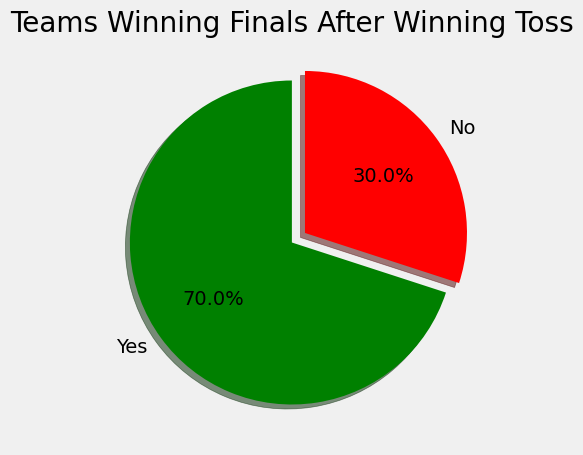

In [86]:
# Teams winning final after winning toss

df = finals[finals['toss_winner'] == finals['winner']]

# Correct slices
slices = [len(df), len(finals) - len(df)]

labels = ['Yes', 'No']

# Plot pie chart
mlt.figure(figsize=(5,5))

mlt.pie(
    slices,
    labels=labels,
    startangle=90,
    shadow=True,
    colors=['green', 'red'],   # FIXED COLORS
    explode=(0, 0.1),
    autopct='%1.1f%%'
)

mlt.title("Teams Winning Finals After Winning Toss")

mlt.show()

83.3%!!! chances is that the toss winning team wins the title. Thats a huge number and thus indication that winning the toss plays a great  role in match winning!!

### Batting Or Fielding For Toss Winners

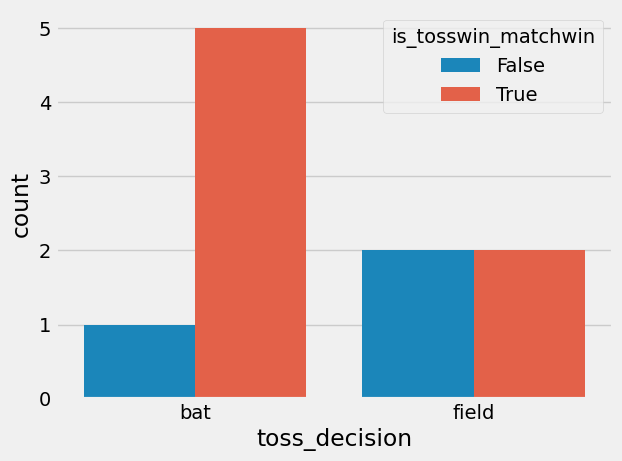

In [87]:
finals['is_tosswin_matchwin']=finals['toss_winner']==finals['winner']
sns.countplot(x='toss_decision',hue='is_tosswin_matchwin',data=finals)
mlt.show()

Looks like after **Winning The Toss** team should opt for **Batting** as we can see that batting has proved to be match winning decision for 4/5 times out of 9 finals.

I will keep updating the notebook as and when I get a new question to be analysed.

**Thank You For Having A Look At This Notebook**

**Please Upvote if this was Helpful**